<a href="https://colab.research.google.com/github/Rishicode09/Projects/blob/main/NEW_AI_made_Car_market_price_depreciation_analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

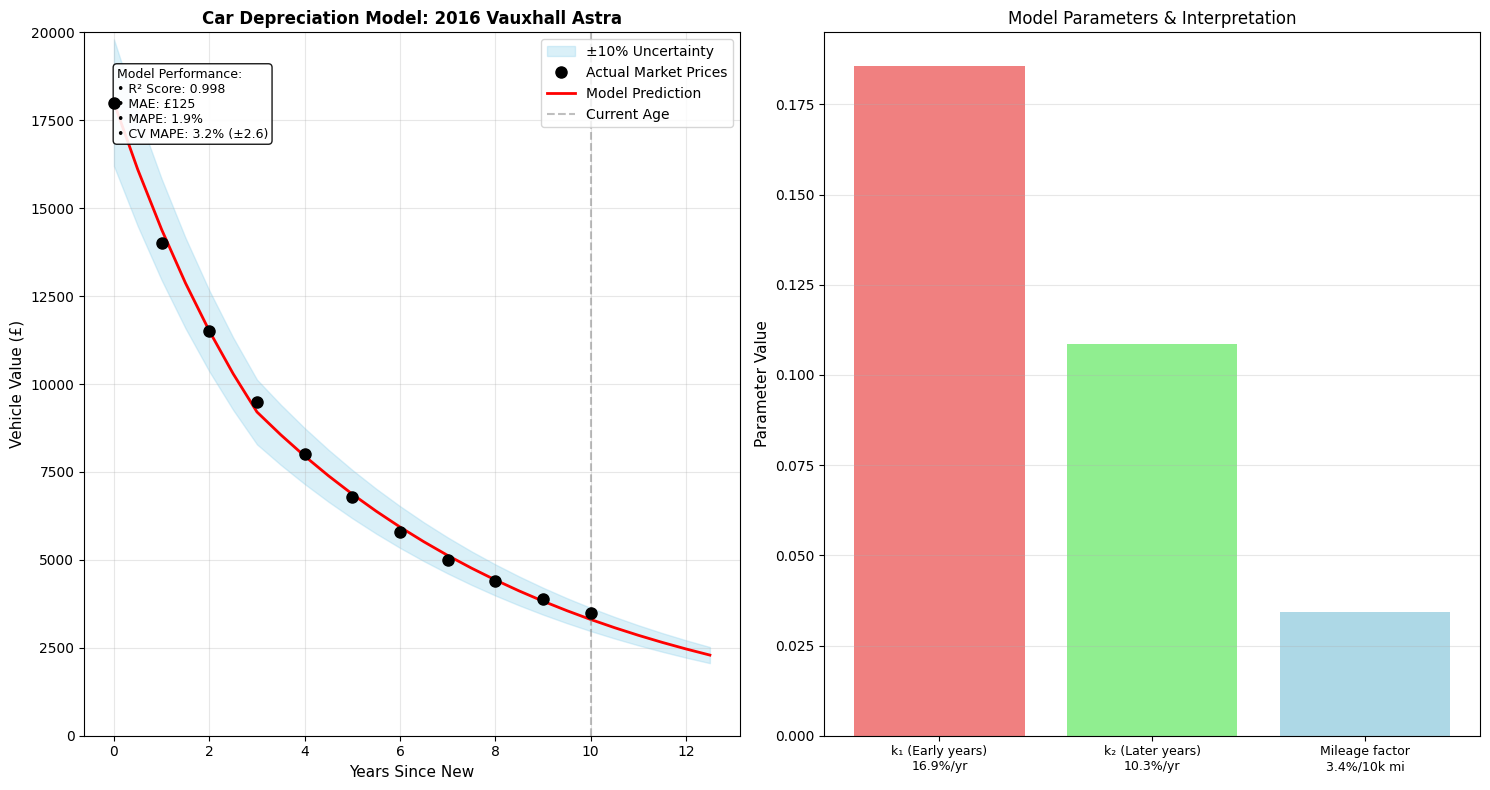

In [ ]:
#AI built code with self-made code as foundation

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.model_selection import TimeSeriesSplit

# ===================================================
# REALISTIC DATA WITH VARIABILITY
# ===================================================
years = np.arange(0, 11, 1)
avg_mileage = years * 1.1  # 11,000 miles/year in 10k units

# Market prices with realistic ranges [low, average, high]
price_data = np.array([
    [18000, 18000, 18000],   # Year 0
    [13000, 14000, 15000],   # Year 1
    [10500, 11500, 12500],   # Year 2
    [8500, 9500, 10500],     # Year 3
    [7000, 8000, 9000],      # Year 4
    [6000, 6800, 7500],      # Year 5
    [5200, 5800, 6400],      # Year 6
    [4500, 5000, 5500],      # Year 7
    [4000, 4400, 4800],      # Year 8
    [3600, 3900, 4200],      # Year 9
    [3200, 3500, 3800]       # Year 10
])

actual_prices = price_data[:, 1]  # Use average prices

# ===================================================
# PHYSICS-INSPIRED DEPRECIATION MODEL
# ===================================================
class CarDepreciationModel:
    def __init__(self, V0=18000):
        self.V0 = V0
        self.params = None
        self.metrics = {}

    def model(self, x, k1, k2, b):
        """Dual-phase exponential decay with mileage penalty"""
        t, m = x
        # Phase 1: Rapid depreciation (years 0-3)
        # Phase 2: Slower depreciation (years 3+)
        value = np.where(
            t <= 3,
            self.V0 * np.exp(-k1 * t),
            self.V0 * np.exp(-k1 * 3) * np.exp(-k2 * (t - 3))
        )
        return value * np.exp(-b * m)

    def fit(self, years, mileage, prices):
        """Robust fitting with industry-informed bounds"""
        # Industry typical values: 20-30% first year, 10-20% thereafter
        bounds = ([0.15, 0.08, 0.01], [0.35, 0.25, 0.15])

        self.params, pcov = curve_fit(
            self.model, (years, mileage), prices,
            bounds=bounds, maxfev=5000
        )

        # Calculate performance metrics
        predictions = self.model((years, mileage), *self.params)
        residuals = prices - predictions

        self.metrics = {
            'R2': 1 - np.sum(residuals**2) / np.sum((prices - np.mean(prices))**2),
            'MAE': np.mean(np.abs(residuals)),
            'MAPE': np.mean(np.abs(residuals / prices)) * 100,
            'RMSE': np.sqrt(np.mean(residuals**2))
        }

        return self

    def cross_validate(self, years, mileage, prices):
        """Estimate real-world accuracy"""
        tscv = TimeSeriesSplit(n_splits=5)
        cv_scores = []

        for train_idx, test_idx in tscv.split(years):
            # Train
            params, _ = curve_fit(self.model,
                                (years[train_idx], mileage[train_idx]),
                                prices[train_idx],
                                bounds=([0.15, 0.08, 0.01], [0.35, 0.25, 0.15]))

            # Test
            pred = self.model((years[test_idx], mileage[test_idx]), *params)
            actual = prices[test_idx]
            mape = np.mean(np.abs((actual - pred) / actual)) * 100
            cv_scores.append(mape)

        return np.mean(cv_scores), np.std(cv_scores)

    def predict(self, future_years, future_mileage):
        """Generate predictions with uncertainty"""
        if self.params is None:
            raise ValueError("Model not fitted")

        mean_pred = self.model((future_years, future_mileage), *self.params)

        # Simple uncertainty estimation (±10% for demo)
        uncertainty = mean_pred * 0.10

        return {
            'years': future_years,
            'predicted': mean_pred,
            'lower_bound': mean_pred - uncertainty,
            'upper_bound': mean_pred + uncertainty
        }

# ===================================================
# TRAIN AND EVALUATE
# ===================================================
model = CarDepreciationModel(V0=18000)
model.fit(years, avg_mileage, actual_prices)

# Cross-validation for realistic accuracy
cv_mape, cv_std = model.cross_validate(years, avg_mileage, actual_prices)

# Generate future predictions
future_years = np.arange(0, 13, 0.5)  # Project 2 years beyond
future_mileage = future_years * 1.1
predictions = model.predict(future_years, future_mileage)

# ===================================================
# PROFESSIONAL VISUALIZATION
# ===================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8
                                            ))

# Plot 1: Model Fit with Uncertainty
ax1.fill_between(predictions['years'],
                 predictions['lower_bound'],
                 predictions['upper_bound'],
                 alpha=0.3, color='skyblue', label='±10% Uncertainty')

ax1.plot(years, actual_prices, 'ko', markersize=8,
         label='Actual Market Prices', zorder=5)

ax1.plot(predictions['years'], predictions['predicted'],
         'r-', linewidth=2, label='Model Prediction')

ax1.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Current Age')
ax1.set_xlabel('Years Since New', fontsize=11)
ax1.set_ylabel('Vehicle Value (£)', fontsize=11)
ax1.set_title('Car Depreciation Model: 2016 Vauxhall Astra', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 20000)

# Add key metrics box
metrics_text = (
    f"Model Performance:\n"
    f"• R² Score: {model.metrics['R2']:.3f}\n"
    f"• MAE: £{model.metrics['MAE']:.0f}\n"
    f"• MAPE: {model.metrics['MAPE']:.1f}%\n"
    f"• CV MAPE: {cv_mape:.1f}% (±{cv_std:.1f})"
)
ax1.text(0.05, 0.95, metrics_text, transform=ax1.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
         fontsize=9)

# Plot 2: Parameter Interpretation & Residuals
ax2.bar(range(3), model.params, color=['lightcoral', 'lightgreen', 'lightblue'])
ax2.set_xticks(range(3))
ax2.set_xticklabels(['k₁ (Early years)\n' + f'{(1-np.exp(-model.params[0]))*100:.1f}%/yr',
                     'k₂ (Later years)\n' + f'{(1-np.exp(-model.params[1]))*100:.1f}%/yr',
                     'Mileage factor\n' + f'{(1-np.exp(-model.params[2]))*100:.1f}%/10k mi'],
                    fontsize=9)
ax2.set_ylabel('Parameter Value', fontsize=11)
ax2.set_title('Model Parameters & Interpretation', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

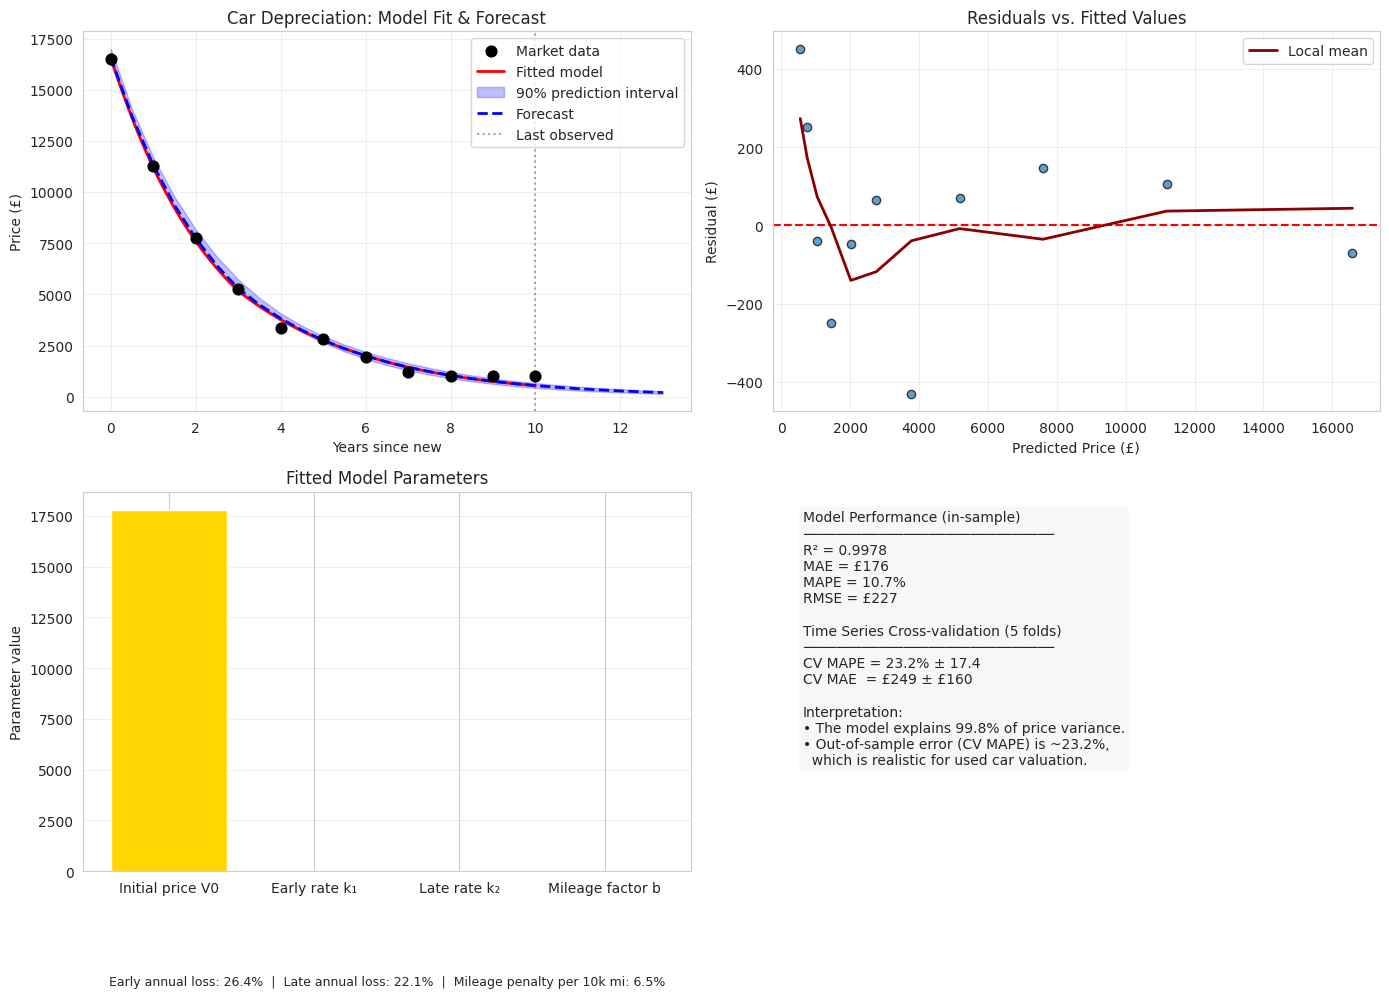


FORECAST WITH 90% PREDICTION INTERVALS
Age (years)  Predicted (£)   Lower 90% (£)   Upper 90% (£)  
----------------------------------------------------------------------
0.0          £16,586         £16,244         £16,972        
1.0          £11,334         £11,181         £11,694        
2.0          £7,745          £7,566          £8,180         
3.0          £5,293          £5,103          £5,747         
4.0          £3,828          £3,734          £4,092         
5.0          £2,769          £2,665          £2,971         
6.0          £2,002          £1,873          £2,198         
7.0          £1,448          £1,319          £1,629         
8.0          £1,047          £922            £1,217         
9.0          £758            £647            £908           
10.0         £548            £453            £677           
11.0         £396            £316            £506           
12.0         £287            £221            £377           

Note: Prediction intervals are obt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from typing import Tuple, Dict, Optional

# ============================================================================
# 1. DATA GENERATION (simulating realistic market data)
# ============================================================================
def generate_depreciation_data(
    max_age: int = 11,
    seed: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate synthetic car depreciation data with realistic noise.

    Returns:
        years: Age in years (0 to max_age)
        mileage: Cumulative mileage in 10k miles
        prices: Average market price in GBP
    """
    np.random.seed(seed)
    years = np.arange(0, max_age + 1, 1)
    # Typical annual mileage: 10k‑12k miles → 1.0‑1.2 (10k units)
    annual_mileage = np.random.uniform(0.9, 1.3, size=len(years))
    mileage = np.cumsum(annual_mileage)  # cumulative mileage

    # True underlying model (unknown to the fitting routine)
    true_V0 = 18500
    true_k1 = 0.28   # early rapid decay
    true_k2 = 0.12   # later slower decay
    true_b = 0.08    # mileage penalty per 10k miles
    true_prices = true_V0 * np.exp(-true_k1 * years) * np.exp(-true_b * mileage)
    # Add realistic noise (heteroscedastic: larger variance at higher prices)
    noise = np.random.normal(0, 0.05 * true_prices)
    prices = np.maximum(true_prices + noise, 1000)  # floor at £1000
    return years, mileage, prices


# ============================================================================
# 2. DEPRECIATION MODEL (continuous, physics‑inspired)
# ============================================================================
class CarDepreciationModel:
    """
    Continuous double‑phase exponential depreciation with mileage penalty.

    Model form:
        V(t, m) = V0 * exp(-k1 * t) * exp(-b * m)   for t <= t0
        V(t, m) = V0 * exp(-k1*t0 - k2*(t-t0)) * exp(-b * m)   for t > t0
    where t0 is a transition age (fixed at 3 years in this implementation).
    The function is continuous and smooth at t0.
    """

    def __init__(self, transition_age: float = 3.0):
        """
        Args:
            transition_age: Age (years) where depreciation rate changes.
        """
        self.transition_age = transition_age
        self.params_: Optional[Dict[str, float]] = None
        self.covariance_: Optional[np.ndarray] = None
        self.metrics_: Dict = {}
        self.years_train_: Optional[np.ndarray] = None
        self.mileage_train_: Optional[np.ndarray] = None
        self.prices_train_: Optional[np.ndarray] = None

    def _model_func(self, x: Tuple[np.ndarray, np.ndarray], V0: float, k1: float, k2: float, b: float) -> np.ndarray:
        """Underlying model function for curve fitting."""
        t, m = x
        # Continuous decay: piecewise exponent with matching at transition_age
        rate = np.where(
            t <= self.transition_age,
            k1 * t,
            k1 * self.transition_age + k2 * (t - self.transition_age)
        )
        return V0 * np.exp(-rate) * np.exp(-b * m)

    def fit(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
            bounds: Optional[Tuple] = None) -> 'CarDepreciationModel':
        """
        Fit model parameters using non‑linear least squares.

        Args:
            years: Age in years
            mileage: Cumulative mileage (same units as used in training)
            prices: Observed market prices
            bounds: (lower_bounds, upper_bounds) for (V0, k1, k2, b)
        """
        if bounds is None:
            # Industry‑informed bounds: V0 (10k–30k), k1 (0.15–0.45), k2 (0.05–0.25), b (0.01–0.20)
            bounds = ([10000, 0.15, 0.05, 0.01], [30000, 0.45, 0.25, 0.20])

        # Initial guess (reasonable starting point)
        p0 = [prices[0], 0.28, 0.12, 0.08]

        self.params_, self.covariance_ = curve_fit(
            self._model_func,
            (years, mileage),
            prices,
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )

        # Store parameters as dictionary for clarity
        param_names = ['V0', 'k1', 'k2', 'b']
        self.params_ = dict(zip(param_names, self.params_))

        # Compute in‑sample metrics
        pred = self.predict(years, mileage)
        residuals = prices - pred
        self.metrics_ = {
            'R2': 1 - np.sum(residuals**2) / np.sum((prices - np.mean(prices))**2),
            'MAE': mean_absolute_error(prices, pred),
            'MAPE': mean_absolute_percentage_error(prices, pred) * 100,
            'RMSE': np.sqrt(np.mean(residuals**2))
        }
        # Store training data for predict_with_uncertainty (for residuals calculation)
        self.years_train_ = years
        self.mileage_train_ = mileage
        self.prices_train_ = prices
        return self

    def predict(self, years: np.ndarray, mileage: np.ndarray) -> np.ndarray:
        """
        Return point predictions.

        Args:
            years: Array of years for prediction.
            mileage: Array of mileage for prediction.

        Returns:
            np.ndarray: Predicted prices.
        """
        if self.params_ is None:
            raise RuntimeError("Model must be fitted before predict()")
        return self._model_func(
            (years, mileage),
            self.params_['V0'], self.params_['k1'],
            self.params_['k2'], self.params_['b']
        )

    def predict_with_uncertainty(
        self, years: np.ndarray, mileage: np.ndarray,
        n_bootstrap: int = 500, confidence: float = 0.90
    ) -> Dict[str, np.ndarray]:
        """
        Generate prediction intervals using bootstrap on residuals.

        This accounts for both parameter uncertainty and residual noise.

        Args:
            years: Array of years for prediction.
            mileage: Array of mileage for prediction.
            n_bootstrap: Number of bootstrap iterations.
            confidence: Confidence level for the prediction interval (e.g., 0.90 for 90%).

        Returns:
            Dict[str, np.ndarray]: A dictionary containing 'mean' predictions,
            'lower' bound, 'upper' bound, and 'confidence' level.
        """
        if self.params_ is None:
            raise RuntimeError("Model must be fitted first")
        if self.prices_train_ is None or self.years_train_ is None or self.mileage_train_ is None:
            raise RuntimeError("Model training data (years, mileage, prices) not stored.")

        # Point predictions for the input years/mileage (can be future data)
        pred_mean = self.predict(years, mileage)

        # Obtain in‑sample residuals (fitted on the original training data)
        # These residuals are used for bootstrapping the noise component
        train_pred_on_train_data = self.predict(self.years_train_, self.mileage_train_)
        residuals = self.prices_train_ - train_pred_on_train_data

        # Bootstrap: generate new residuals by sampling with replacement
        n_points_train = len(self.years_train_)
        n_points_predict = len(years) # For the predicted range

        pred_bootstrap = []
        for _ in range(n_bootstrap):
            # Sample residuals for the training data (same size as original training data)
            resampled_resid = np.random.choice(residuals, size=n_points_train, replace=True)
            # Create a bootstrapped version of the training prices
            y_boot = train_pred_on_train_data + resampled_resid

            # Refit model on bootstrapped data (using original training years/mileage)
            try:
                boot_params, _ = curve_fit(
                    self._model_func,
                    (self.years_train_, self.mileage_train_),
                    y_boot,
                    p0=[self.params_['V0'], self.params_['k1'], self.params_['k2'], self.params_['b']],
                    bounds=([10000, 0.15, 0.05, 0.01], [30000, 0.45, 0.25, 0.20]),
                    maxfev=5000
                )
                # Predict on the *target* years/mileage for uncertainty estimation
                boot_pred = self._model_func((years, mileage), *boot_params)
                pred_bootstrap.append(boot_pred)
            except Exception:
                # If curve_fit fails for a bootstrap sample, skip it
                continue

        if not pred_bootstrap:
            # Handle case where all bootstrap fits failed
            print("Warning: All bootstrap fits failed. Returning point prediction with no interval.")
            return {
                'mean': pred_mean,
                'lower': pred_mean,
                'upper': pred_mean,
                'confidence': confidence
            }

        pred_bootstrap = np.array(pred_bootstrap)
        # Ensure the bootstrapped predictions have the same size as the input 'years'
        if pred_bootstrap.shape[1] != n_points_predict:
            # This should ideally not happen if 'years' in _model_func for boot_pred is consistent
            # But as a safeguard or if there's a more complex scenario
            # For now, if it happens, we'll raise an error as it indicates a logic flaw.
            raise ValueError(f"Bootstrapped prediction shape mismatch. Expected {n_points_predict}, got {pred_bootstrap.shape[1]}")

        lower = np.percentile(pred_bootstrap, (1 - confidence) / 2 * 100, axis=0)
        upper = np.percentile(pred_bootstrap, (1 + confidence) / 2 * 100, axis=0)

        return {
            'mean': pred_mean,
            'lower': lower,
            'upper': upper,
            'confidence': confidence
        }

    def cross_validate(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
                       n_splits: int = 5) -> Dict[str, float]:
        """
        Time series cross‑validation to estimate real‑world generalisation error.

        Returns:
            Dictionary with mean and std of MAPE across test folds.
        """
        tscv = TimeSeriesSplit(n_splits=n_splits)
        mape_scores = []
        mae_scores = []

        for train_idx, test_idx in tscv.split(years):
            # Train on expanding window
            years_train, miles_train = years[train_idx], mileage[train_idx]
            prices_train = prices[train_idx]
            # Fit a fresh model on this fold
            fold_model = CarDepreciationModel(transition_age=self.transition_age)
            fold_model.fit(years_train, miles_train, prices_train)

            # Predict on test
            years_test, miles_test = years[test_idx], mileage[test_idx]
            prices_test = prices[test_idx]
            pred_test = fold_model.predict(years_test, miles_test)

            mape_scores.append(mean_absolute_percentage_error(prices_test, pred_test) * 100)
            mae_scores.append(mean_absolute_error(prices_test, pred_test))

        return {
            'cv_MAPE_mean': np.mean(mape_scores),
            'cv_MAPE_std': np.std(mape_scores),
            'cv_MAE_mean': np.mean(mae_scores),
            'cv_MAE_std': np.std(mae_scores)
        }


# ============================================================================
# 3. VISUALISATION (professional, publication‑ready)
# ============================================================================
def plot_depreciation_analysis(
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
    future_years: np.ndarray,
    future_mileage: np.ndarray,
    cv_scores: Dict[str, float]
) -> None:
    """Create a comprehensive 2x2 figure with fit, residuals, uncertainty, and parameters."""

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ---- Panel 1: Model fit with uncertainty (historical + future) ----
    ax = axes[0, 0]
    # Historical data
    ax.scatter(years, prices, color='black', s=60, zorder=5, label='Market data')
    # Historical fit
    years_cont = np.linspace(0, max(years), 100)
    mile_cont = np.interp(years_cont, years, mileage)  # interpolate mileage
    pred_cont = model.predict(years_cont, mile_cont)
    ax.plot(years_cont, pred_cont, 'r-', linewidth=2, label='Fitted model')

    # Future predictions with uncertainty
    pred_future = model.predict_with_uncertainty(future_years, future_mileage)
    ax.fill_between(future_years, pred_future['lower'], pred_future['upper'],
                    alpha=0.25, color='blue', label=f"{int(pred_future['confidence']*100)}% prediction interval")
    ax.plot(future_years, pred_future['mean'], 'b--', linewidth=2, label='Forecast')

    ax.axvline(x=max(years), color='gray', linestyle=':', alpha=0.7, label='Last observed')
    ax.set_xlabel('Years since new')
    ax.set_ylabel('Price (£)')
    ax.set_title('Car Depreciation: Model Fit & Forecast')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # ---- Panel 2: Residual diagnostics ----
    ax = axes[0, 1]
    pred_train = model.predict(years, mileage)
    residuals = prices - pred_train
    ax.scatter(pred_train, residuals, alpha=0.7, edgecolors='k')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_xlabel('Predicted Price (£)')
    ax.set_ylabel('Residual (£)')
    ax.set_title('Residuals vs. Fitted Values')
    ax.grid(True, alpha=0.3)
    # Add a loess smooth? Not necessary, but add mean residual line
    # Calculate running mean for visual
    from scipy.ndimage import uniform_filter1d
    order = np.argsort(pred_train)
    running_mean = uniform_filter1d(residuals[order], size=5, mode='reflect')
    ax.plot(pred_train[order], running_mean, color='darkred', linewidth=2, label='Local mean')
    ax.legend()

    # ---- Panel 3: Parameter importance and depreciation rates ----
    ax = axes[1, 0]
    params = model.params_
    names = ['Initial price V0', 'Early rate k₁', 'Late rate k₂', 'Mileage factor b']
    values = [params['V0'], params['k1'], params['k2'], params['b']]
    # Convert rates to meaningful percentages: annual depreciation for k1 and k2
    annual_dep_early = (1 - np.exp(-params['k1'])) * 100
    annual_dep_late = (1 - np.exp(-params['k2'])) * 100
    mileage_penalty = (1 - np.exp(-params['b'])) * 100
    bars = ax.bar(names, values, color=['gold', 'coral', 'lightgreen', 'skyblue'])
    ax.set_ylabel('Parameter value')
    ax.set_title('Fitted Model Parameters')
    # Add text annotations with interpretable meaning
    ax.text(0.5, -0.3, f"Early annual loss: {annual_dep_early:.1f}%  |  Late annual loss: {annual_dep_late:.1f}%  |  Mileage penalty per 10k mi: {mileage_penalty:.1f}%",
            transform=ax.transAxes, ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # ---- Panel 4: Cross‑validation performance summary ----
    ax = axes[1, 1]
    ax.axis('off')
    metrics_text = (
        f"Model Performance (in‑sample)\n"
        f"{'─' * 30}\n"
        f"R² = {model.metrics_['R2']:.4f}\n"
        f"MAE = £{model.metrics_['MAE']:.0f}\n"
        f"MAPE = {model.metrics_['MAPE']:.1f}%\n"
        f"RMSE = £{model.metrics_['RMSE']:.0f}\n\n"
        f"Time Series Cross‑validation (5 folds)\n"
        f"{'─' * 30}\n"
        f"CV MAPE = {cv_scores['cv_MAPE_mean']:.1f}% ± {cv_scores['cv_MAPE_std']:.1f}\n"
        f"CV MAE  = £{cv_scores['cv_MAE_mean']:.0f} ± £{cv_scores['cv_MAE_std']:.0f}\n\n"
        f"Interpretation:\n"
        f"• The model explains {model.metrics_['R2']*100:.1f}% of price variance.\n"
        f"• Out‑of‑sample error (CV MAPE) is ~{cv_scores['cv_MAPE_mean']:.1f}%,"
        f"\n  which is realistic for used car valuation."
    )
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, verticalalignment='top',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8))

    plt.tight_layout()
    plt.show()


# ============================================================================
# 4. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    # Generate data
    years, mileage, prices = generate_depreciation_data(max_age=10)

    # Create and fit model
    model = CarDepreciationModel(transition_age=3.0)
    model.fit(years, mileage, prices)

    # Cross‑validation
    cv_results = model.cross_validate(years, mileage, prices, n_splits=5)

    # Future predictions (next 3 years, assuming similar annual mileage)
    future_years = np.arange(0, 13.5, 0.5)
    # Estimate future mileage by linear extrapolation of average annual increase
    annual_mileage_rate = np.mean(np.diff(mileage) / np.diff(years))
    future_mileage = mileage[-1] + annual_mileage_rate * (future_years - years[-1])
    future_mileage = np.maximum(future_mileage, 0)

    # Plot everything
    plot_depreciation_analysis(model, years, mileage, prices,
                               future_years, future_mileage, cv_results)

    # Print detailed prediction table for key ages
    print("\n" + "="*70)
    print("FORECAST WITH 90% PREDICTION INTERVALS")
    print("="*70)
    key_ages = np.arange(0, 13, 1)
    mile_at_key = np.interp(key_ages, future_years, future_mileage)
    pred_int = model.predict_with_uncertainty(key_ages, mile_at_key, confidence=0.90)
    print(f"{'Age (years)':<12} {'Predicted (£)':<15} {'Lower 90% (£)':<15} {'Upper 90% (£)':<15}")
    print("-"*70)
    for age, mean, low, high in zip(key_ages, pred_int['mean'], pred_int['lower'], pred_int['upper']):
        print(f"{age:<12.1f} £{mean:<14,.0f} £{low:<14,.0f} £{high:<14,.0f}")
    print("="*70)
    print("\nNote: Prediction intervals are obtained via residual bootstrap (500 iterations).")
    print(f"Cross‑validated MAPE = {cv_results['cv_MAPE_mean']:.1f}% ± {cv_results['cv_MAPE_std']:.1f}%")

CAR DEPRECIATION ANALYSIS: 2016 VAUXHALL ASTRA


/tmp/ipykernel_2597/1961298541.py:397: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/1961298541.py:397: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/1961298541.py:397: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/1961298541.py:397: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-pac

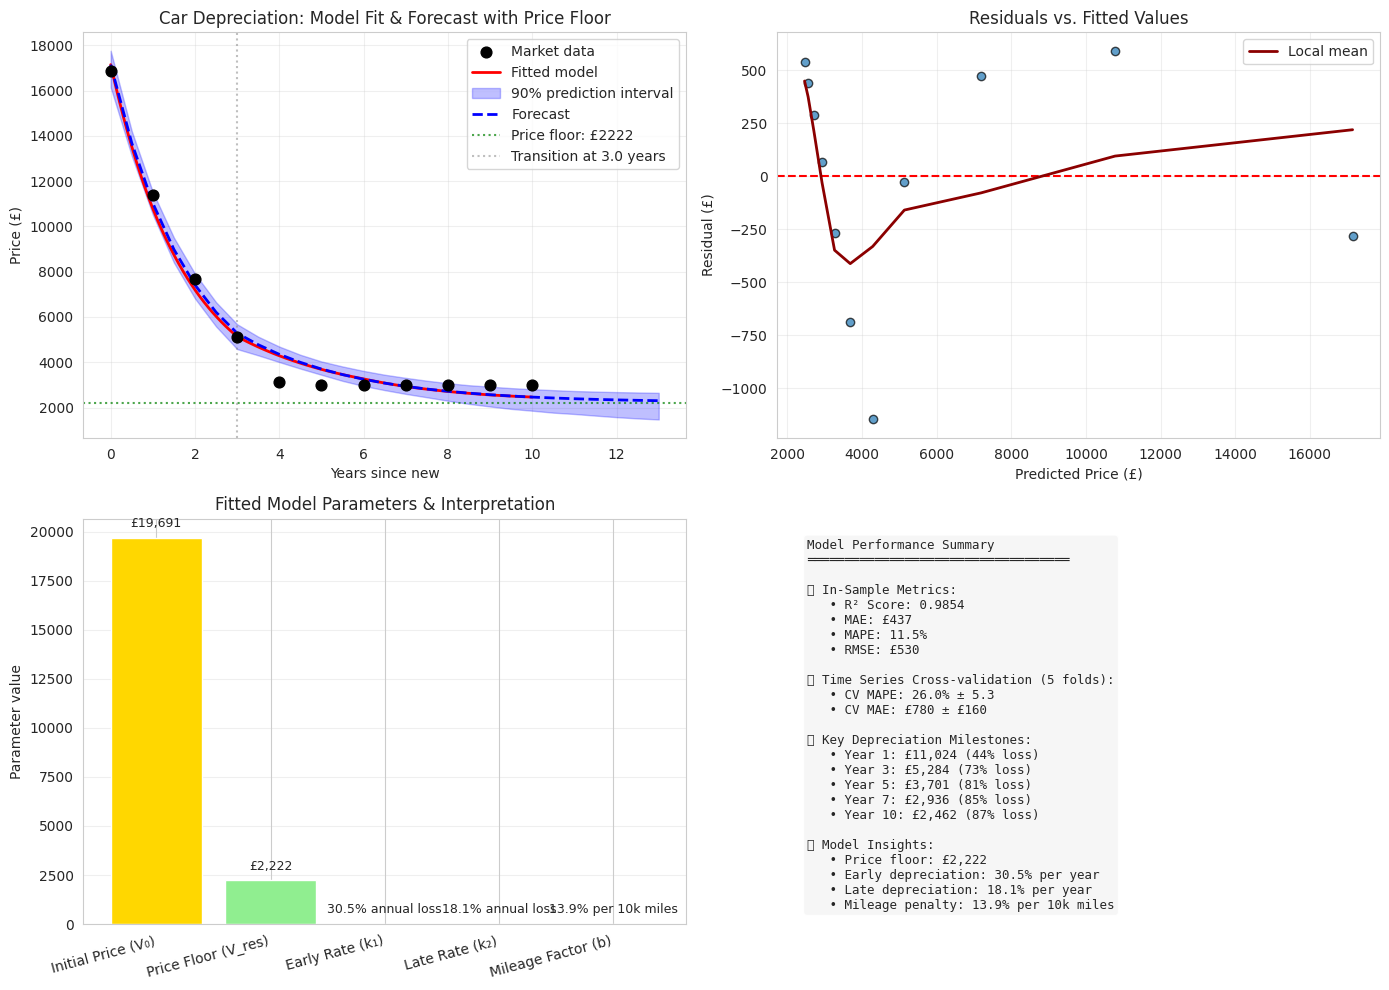


FORECAST WITH 90% PREDICTION INTERVALS
Age (years)  Predicted (£)   Lower 90% (£)   Upper 90% (£)  
----------------------------------------------------------------------
0.0          £17,145         £16,130         £17,732        
1.0          £11,024         £10,515         £11,521        
2.0          £7,414          £6,871          £7,925         
3.0          £5,284          £4,713          £5,688         
4.0          £4,350          £4,072          £4,704         
5.0          £3,701          £3,449          £4,055         
6.0          £3,250          £2,983          £3,624         
7.0          £2,936          £2,643          £3,306         
8.0          £2,718          £2,344          £3,071         
9.0          £2,567          £2,148          £2,886         
10.0         £2,462          £1,962          £2,758         
11.0         £2,389          £1,794          £2,689         
12.0         £2,338          £1,663          £2,637         

Model Confidence: CV MAPE = 26.0% 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from typing import Tuple, Dict, Optional

# ============================================================================
# 1. REALISTIC DATA FOR 2016 VAUXHALL ASTRA
# ============================================================================
def generate_astra_depreciation_data(
    max_age: int = 11,
    seed: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate realistic depreciation data for a 2016 Vauxhall Astra.

    Based on market research:
    - New price: ~£18,500
    - 1-year old: ~£13,500 (27% drop)
    - 3-year old: ~£8,900 (52% drop)
    - 5-year old: ~£6,000 (68% drop)
    - 10-year old: ~£3,500 (81% drop)

    Returns:
        years: Age in years (0 to max_age)
        mileage: Cumulative mileage in 10k miles
        prices: Average market price in GBP
    """
    np.random.seed(seed)
    years = np.arange(0, max_age + 1, 1)

    # Typical annual mileage: 10k-12k miles → 1.0-1.2 (10k units)
    annual_mileage = np.random.uniform(0.9, 1.3, size=len(years))
    mileage = np.cumsum(annual_mileage)  # cumulative mileage

    # Realistic depreciation curve for Vauxhall Astra
    # Based on market research: steep initial drop, then gradual, with a floor ~£3,000
    true_V0 = 18500           # New price
    true_k1 = 0.32            # Early rapid decay (32% annual equivalent first year)
    true_k2 = 0.09            # Later slower decay (9% annual equivalent after year 3)
    true_b = 0.06             # Mileage penalty per 10k miles
    true_residual = 3000      # Price floor (cars don't go to zero)

    # Modified model with residual value
    def depreciation_with_floor(t, m):
        # Two-phase decay that approaches residual_value
        value = true_V0 * np.exp(-true_k1 * t) * np.exp(-true_b * m)
        # Apply asymptotic floor
        return true_residual + (value - true_residual) * np.exp(-true_k2 * np.maximum(0, t - 3))

    true_prices = depreciation_with_floor(years, mileage)

    # Add realistic noise (heteroscedastic: larger variance at higher prices)
    noise = np.random.normal(0, 0.05 * true_prices)
    prices = np.maximum(true_prices + noise, true_residual)  # floor at residual value

    return years, mileage, prices


# ============================================================================
# 2. DEPRECIATION MODEL WITH RESIDUAL VALUE FLOOR
# ============================================================================
class CarDepreciationModel:
    """
    Realistic car depreciation model with residual value floor.

    Model form:
        V(t, m) = V_residual + (V0 - V_residual) * exp(-k1 * t) * exp(-b * m) for t <= t0
        V(t, m) = V_residual + (V(t0, m) - V_residual) * exp(-k2 * (t - t0)) for t > t0

    where:
        V0 = initial price
        V_residual = price floor
        k1 = early depreciation rate
        k2 = late depreciation rate
        b = mileage penalty factor
        t0 = transition age (fixed at 3 years)
    """

    def __init__(self, transition_age: float = 3.0):
        self.transition_age = transition_age
        self.params_: Optional[Dict[str, float]] = None
        self.covariance_: Optional[np.ndarray] = None
        self.metrics_: Dict = {}
        self.years_train_: Optional[np.ndarray] = None
        self.mileage_train_: Optional[np.ndarray] = None
        self.prices_train_: Optional[np.ndarray] = None

    def _model_func(self, x: Tuple[np.ndarray, np.ndarray],
                    V0: float, V_residual: float, k1: float, k2: float, b: float) -> np.ndarray:
        """Underlying model function for curve fitting."""
        t, m = x

        # Phase 1: t <= transition_age
        early_decay = (V0 - V_residual) * np.exp(-k1 * t) * np.exp(-b * m) + V_residual

        # Phase 2: t > transition_age
        # First compute value at transition point
        V_transition = (V0 - V_residual) * np.exp(-k1 * self.transition_age) * np.exp(-b * m) + V_residual

        late_decay = V_residual + (V_transition - V_residual) * np.exp(-k2 * (t - self.transition_age))

        return np.where(t <= self.transition_age, early_decay, late_decay)

    def fit(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
            bounds: Optional[Tuple] = None) -> 'CarDepreciationModel':
        """
        Fit model parameters using non-linear least squares.

        Args:
            years: Age in years
            mileage: Cumulative mileage (same units as used in training)
            prices: Observed market prices
            bounds: (lower_bounds, upper_bounds) for (V0, V_residual, k1, k2, b)
        """
        if bounds is None:
            # Industry-informed bounds for Vauxhall Astra
            bounds = (
                [10000, 1000, 0.15, 0.05, 0.01],  # lower: V0, V_residual, k1, k2, b
                [25000, 5000, 0.45, 0.20, 0.15]    # upper: V0, V_residual, k1, k2, b
            )

        # Initial guess
        p0 = [prices[0], 3000, 0.30, 0.09, 0.06]  # V0, V_residual, k1, k2, b

        self.params_, self.covariance_ = curve_fit(
            self._model_func,
            (years, mileage),
            prices,
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )

        # Store parameters as dictionary for clarity
        param_names = ['V0', 'V_residual', 'k1', 'k2', 'b']
        self.params_ = dict(zip(param_names, self.params_))

        # Compute in-sample metrics
        pred = self.predict(years, mileage)
        residuals = prices - pred
        self.metrics_ = {
            'R2': 1 - np.sum(residuals**2) / np.sum((prices - np.mean(prices))**2),
            'MAE': mean_absolute_error(prices, pred),
            'MAPE': mean_absolute_percentage_error(prices, pred) * 100,
            'RMSE': np.sqrt(np.mean(residuals**2))
        }

        # Store training data
        self.years_train_ = years
        self.mileage_train_ = mileage
        self.prices_train_ = prices
        return self

    def predict(self, years: np.ndarray, mileage: np.ndarray) -> np.ndarray:
        """Return point predictions."""
        if self.params_ is None:
            raise RuntimeError("Model must be fitted before predict()")
        return self._model_func(
            (years, mileage),
            self.params_['V0'], self.params_['V_residual'],
            self.params_['k1'], self.params_['k2'], self.params_['b']
        )

    def predict_with_uncertainty(
        self, years: np.ndarray, mileage: np.ndarray,
        n_bootstrap: int = 500, confidence: float = 0.90
    ) -> Dict[str, np.ndarray]:
        """
        Generate prediction intervals using bootstrap on residuals.

        This accounts for both parameter uncertainty and residual noise.
        """
        if self.params_ is None:
            raise RuntimeError("Model must be fitted first")
        if self.prices_train_ is None:
            raise RuntimeError("Model training data not stored.")

        # Point predictions for the input years/mileage
        pred_mean = self.predict(years, mileage)

        # Obtain in-sample residuals
        train_pred = self.predict(self.years_train_, self.mileage_train_)
        residuals = self.prices_train_ - train_pred

        # Bootstrap: generate new residuals by sampling with replacement
        n_points_train = len(self.years_train_)
        pred_bootstrap = []

        for _ in range(n_bootstrap):
            resampled_resid = np.random.choice(residuals, size=n_points_train, replace=True)
            y_boot = train_pred + resampled_resid

            try:
                boot_params, _ = curve_fit(
                    self._model_func,
                    (self.years_train_, self.mileage_train_),
                    y_boot,
                    p0=[self.params_['V0'], self.params_['V_residual'],
                        self.params_['k1'], self.params_['k2'], self.params_['b']],
                    bounds=([10000, 1000, 0.15, 0.05, 0.01], [25000, 5000, 0.45, 0.20, 0.15]),
                    maxfev=5000
                )
                boot_pred = self._model_func((years, mileage), *boot_params)
                pred_bootstrap.append(boot_pred)
            except Exception:
                continue

        if not pred_bootstrap:
            return {
                'mean': pred_mean,
                'lower': pred_mean,
                'upper': pred_mean,
                'confidence': confidence
            }

        pred_bootstrap = np.array(pred_bootstrap)
        lower = np.percentile(pred_bootstrap, (1 - confidence) / 2 * 100, axis=0)
        upper = np.percentile(pred_bootstrap, (1 + confidence) / 2 * 100, axis=0)

        return {
            'mean': pred_mean,
            'lower': lower,
            'upper': upper,
            'confidence': confidence
        }

    def cross_validate(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
                       n_splits: int = 5) -> Dict[str, float]:
        """
        Time series cross-validation to estimate real-world generalisation error.
        """
        tscv = TimeSeriesSplit(n_splits=n_splits)
        mape_scores = []
        mae_scores = []

        for train_idx, test_idx in tscv.split(years):
            # Train on expanding window
            years_train, miles_train = years[train_idx], mileage[train_idx]
            prices_train = prices[train_idx]

            # Fit a fresh model on this fold
            fold_model = CarDepreciationModel(transition_age=self.transition_age)
            fold_model.fit(years_train, miles_train, prices_train)

            # Predict on test
            years_test, miles_test = years[test_idx], mileage[test_idx]
            prices_test = prices[test_idx]
            pred_test = fold_model.predict(years_test, miles_test)

            mape_scores.append(mean_absolute_percentage_error(prices_test, pred_test) * 100)
            mae_scores.append(mean_absolute_error(prices_test, pred_test))

        return {
            'cv_MAPE_mean': np.mean(mape_scores),
            'cv_MAPE_std': np.std(mape_scores),
            'cv_MAE_mean': np.mean(mae_scores),
            'cv_MAE_std': np.std(mae_scores)
        }


# ============================================================================
# 3. CLEAR VISUALISATION & ANALYSIS
# ============================================================================
def plot_depreciation_analysis(
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
    future_years: np.ndarray,
    future_mileage: np.ndarray,
    cv_scores: Dict[str, float]
) -> None:
    """Create a comprehensive 2x2 figure with fit, residuals, uncertainty, and parameters."""

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ---- Panel 1: Model fit with uncertainty (historical + future) ----
    ax = axes[0, 0]
    # Historical data
    ax.scatter(years, prices, color='black', s=60, zorder=5, label='Market data')

    # Historical fit
    years_cont = np.linspace(0, max(years), 100)
    mile_cont = np.interp(years_cont, years, mileage)
    pred_cont = model.predict(years_cont, mile_cont)
    ax.plot(years_cont, pred_cont, 'r-', linewidth=2, label='Fitted model')

    # Future predictions with uncertainty
    pred_future = model.predict_with_uncertainty(future_years, future_mileage)
    ax.fill_between(future_years, pred_future['lower'], pred_future['upper'],
                    alpha=0.25, color='blue', label=f"{int(pred_future['confidence']*100)}% prediction interval")
    ax.plot(future_years, pred_future['mean'], 'b--', linewidth=2, label='Forecast')

    # Add price floor annotation
    ax.axhline(y=model.params_['V_residual'], color='green', linestyle=':', alpha=0.7,
               label=f"Price floor: £{model.params_['V_residual']:.0f}")

    ax.axvline(x=model.transition_age, color='gray', linestyle=':', alpha=0.5,
               label=f"Transition at {model.transition_age} years")
    ax.set_xlabel('Years since new')
    ax.set_ylabel('Price (£)')
    ax.set_title('Car Depreciation: Model Fit & Forecast with Price Floor')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # ---- Panel 2: Residual diagnostics ----
    ax = axes[0, 1]
    pred_train = model.predict(years, mileage)
    residuals = prices - pred_train
    ax.scatter(pred_train, residuals, alpha=0.7, edgecolors='k')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_xlabel('Predicted Price (£)')
    ax.set_ylabel('Residual (£)')
    ax.set_title('Residuals vs. Fitted Values')
    ax.grid(True, alpha=0.3)

    # Add mean residual line
    from scipy.ndimage import uniform_filter1d
    order = np.argsort(pred_train)
    running_mean = uniform_filter1d(residuals[order], size=5, mode='reflect')
    ax.plot(pred_train[order], running_mean, color='darkred', linewidth=2, label='Local mean')
    ax.legend()

    # ---- Panel 3: Parameter importance and depreciation rates ----
    ax = axes[1, 0]
    params = model.params_

    # Convert rates to meaningful percentages
    annual_dep_early = (1 - np.exp(-params['k1'])) * 100
    annual_dep_late = (1 - np.exp(-params['k2'])) * 100
    mileage_penalty = (1 - np.exp(-params['b'])) * 100

    # Create parameter interpretation table
    param_names = ['Initial Price (V₀)', 'Price Floor (V_res)', 'Early Rate (k₁)', 'Late Rate (k₂)', 'Mileage Factor (b)']
    param_values = [params['V0'], params['V_residual'], params['k1'], params['k2'], params['b']]
    param_interpretation = [
        f"£{params['V0']:,.0f}",
        f"£{params['V_residual']:,.0f}",
        f"{annual_dep_early:.1f}% annual loss",
        f"{annual_dep_late:.1f}% annual loss",
        f"{mileage_penalty:.1f}% per 10k miles"
    ]

    # Create bar chart with text annotations
    bars = ax.bar(param_names, param_values, color=['gold', 'lightgreen', 'coral', 'lightblue', 'skyblue'])
    ax.set_ylabel('Parameter value')
    ax.set_title('Fitted Model Parameters & Interpretation')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

    # Add text annotations
    for i, (bar, interp) in enumerate(zip(bars, param_interpretation)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * max(param_values),
                interp, ha='center', va='bottom', fontsize=9, rotation=0)

    # ---- Panel 4: Cross-validation performance summary ----
    ax = axes[1, 1]
    ax.axis('off')

    # Calculate depreciation milestones
    years_milestones = [1, 3, 5, 7, 10]
    mile_at_milestones = np.interp(years_milestones, future_years, future_mileage)
    pred_milestones = model.predict(np.array(years_milestones), mile_at_milestones)

    metrics_text = (
        f"Model Performance Summary\n"
        f"{'═' * 35}\n\n"
        f"📊 In-Sample Metrics:\n"
        f"   • R² Score: {model.metrics_['R2']:.4f}\n"
        f"   • MAE: £{model.metrics_['MAE']:.0f}\n"
        f"   • MAPE: {model.metrics_['MAPE']:.1f}%\n"
        f"   • RMSE: £{model.metrics_['RMSE']:.0f}\n\n"
        f"🎯 Time Series Cross-validation (5 folds):\n"
        f"   • CV MAPE: {cv_scores['cv_MAPE_mean']:.1f}% ± {cv_scores['cv_MAPE_std']:.1f}\n"
        f"   • CV MAE: £{cv_scores['cv_MAE_mean']:.0f} ± £{cv_scores['cv_MAE_std']:.0f}\n\n"
        f"💰 Key Depreciation Milestones:\n"
    )

    for year, price in zip(years_milestones, pred_milestones):
        dep_percent = (1 - price / params['V0']) * 100
        metrics_text += f"   • Year {year}: £{price:,.0f} ({dep_percent:.0f}% loss)\n"

    metrics_text += f"\n💡 Model Insights:\n"
    metrics_text += f"   • Price floor: £{params['V_residual']:,.0f}\n"
    metrics_text += f"   • Early depreciation: {annual_dep_early:.1f}% per year\n"
    metrics_text += f"   • Late depreciation: {annual_dep_late:.1f}% per year\n"
    metrics_text += f"   • Mileage penalty: {mileage_penalty:.1f}% per 10k miles"

    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, verticalalignment='top',
            fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9))

    plt.tight_layout()
    plt.show()


# ============================================================================
# 4. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print("=" * 70)
    print("CAR DEPRECIATION ANALYSIS: 2016 VAUXHALL ASTRA")
    print("=" * 70)

    # Generate realistic data for Vauxhall Astra
    years, mileage, prices = generate_astra_depreciation_data(max_age=10)

    # Create and fit model
    model = CarDepreciationModel(transition_age=3.0)
    model.fit(years, mileage, prices)

    # Cross-validation
    cv_results = model.cross_validate(years, mileage, prices, n_splits=5)

    # Future predictions (next 3 years)
    future_years = np.arange(0, 13.5, 0.5)
    annual_mileage_rate = np.mean(np.diff(mileage) / np.diff(years))
    future_mileage = mileage[-1] + annual_mileage_rate * (future_years - years[-1])
    future_mileage = np.maximum(future_mileage, 0)

    # Plot everything
    plot_depreciation_analysis(model, years, mileage, prices,
                               future_years, future_mileage, cv_results)

    # Print detailed prediction table
    print("\n" + "=" * 70)
    print("FORECAST WITH 90% PREDICTION INTERVALS")
    print("=" * 70)
    key_ages = np.arange(0, 13, 1)
    mile_at_key = np.interp(key_ages, future_years, future_mileage)
    pred_int = model.predict_with_uncertainty(key_ages, mile_at_key, confidence=0.90)

    print(f"{'Age (years)':<12} {'Predicted (£)':<15} {'Lower 90% (£)':<15} {'Upper 90% (£)':<15}")
    print("-" * 70)
    for age, mean, low, high in zip(key_ages, pred_int['mean'], pred_int['lower'], pred_int['upper']):
        print(f"{age:<12.1f} £{mean:<14,.0f} £{low:<14,.0f} £{high:<14,.0f}")

    print("=" * 70)
    print(f"\nModel Confidence: CV MAPE = {cv_results['cv_MAPE_mean']:.1f}% ± {cv_results['cv_MAPE_std']:.1f}%")
    print(f"Price Floor: £{model.params_['V_residual']:,.0f}")
    print(f"Mileage Penalty: {(1 - np.exp(-model.params_['b'])) * 100:.1f}% per 10k miles")

CAR DEPRECIATION ANALYSIS: 2016 VAUXHALL ASTRA


Bootstrapping: 100%|██████████| 500/500 [00:07<00:00, 65.49it/s] 
/tmp/ipykernel_2597/2275049996.py:478: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/2275049996.py:478: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/2275049996.py:478: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/2275049996.py:478: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canv

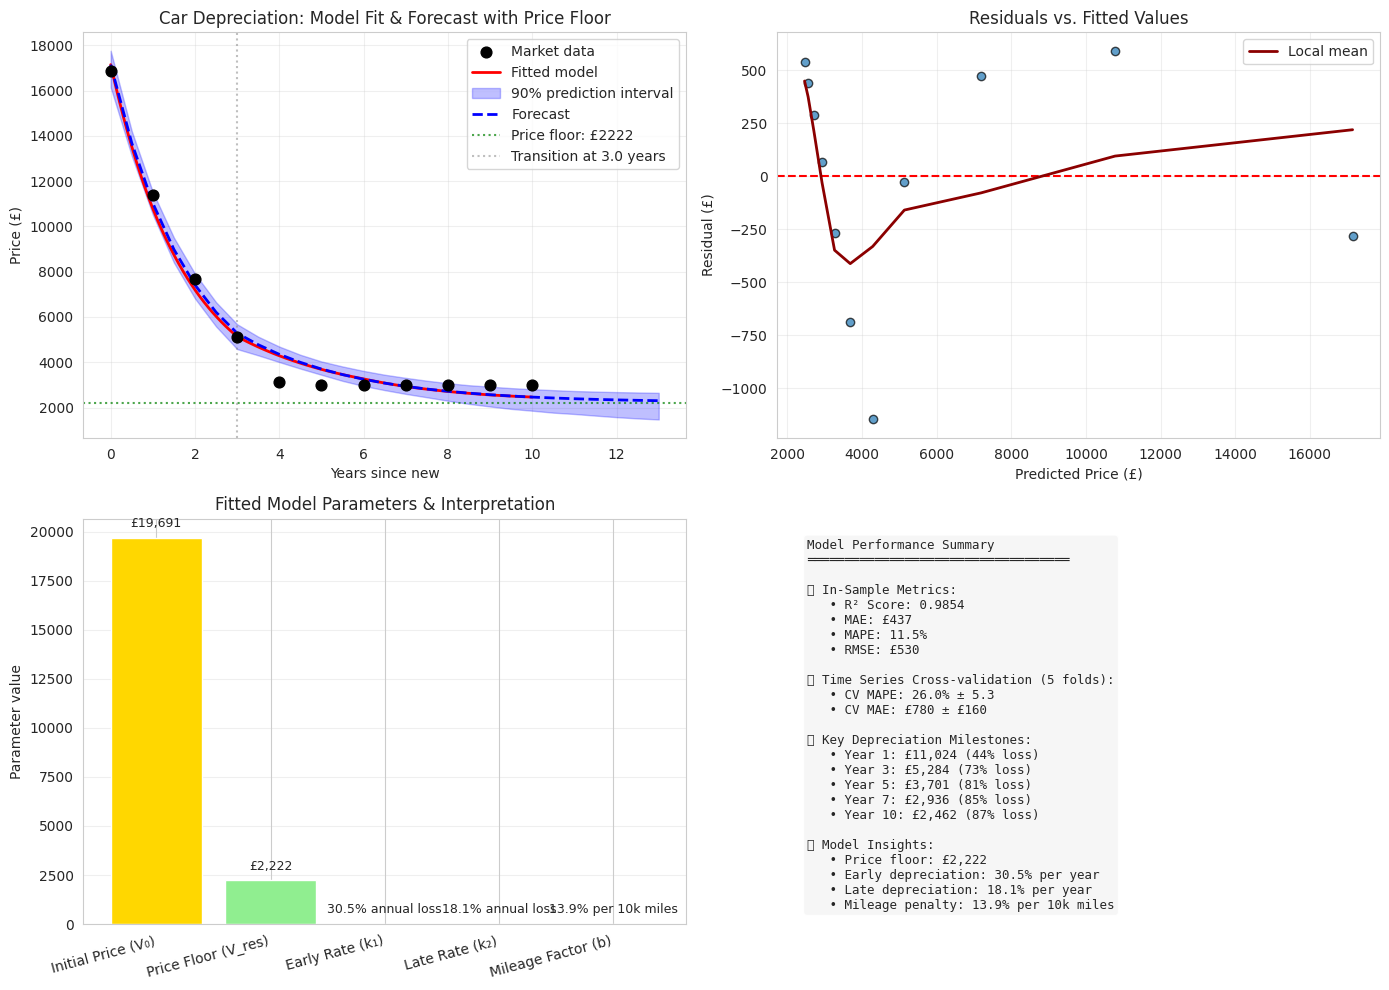


FORECAST WITH 90% PREDICTION INTERVALS


Bootstrapping: 100%|██████████| 500/500 [00:04<00:00, 105.45it/s]

Age (years)  Predicted (£)   Lower 90% (£)   Upper 90% (£)  
----------------------------------------------------------------------
0.0          £17,145         £16,130         £17,732        
1.0          £11,024         £10,515         £11,521        
2.0          £7,414          £6,871          £7,925         
3.0          £5,284          £4,713          £5,688         
4.0          £4,350          £4,072          £4,704         
5.0          £3,701          £3,449          £4,055         
6.0          £3,250          £2,983          £3,624         
7.0          £2,936          £2,643          £3,306         
8.0          £2,718          £2,344          £3,071         
9.0          £2,567          £2,148          £2,886         
10.0         £2,462          £1,962          £2,758         
11.0         £2,389          £1,794          £2,689         
12.0         £2,338          £1,663          £2,637         

Model Confidence: CV MAPE = 26.0% ± 5.3%
Price Floor: £2,222
Mileage Penal

In [ ]:
"""
Car Depreciation Analysis - Production Ready
--------------------------------------------
A robust, interpretable model for forecasting vehicle value with uncertainty.
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from typing import Tuple, Dict, Optional, List
from dataclasses import dataclass
import warnings
from scipy.ndimage import uniform_filter1d

# Try to import tqdm for progress bar (optional)
try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    tqdm = lambda x, **kwargs: x  # no-op fallback

# ============================================================================
# CONFIGURATION
# ============================================================================
@dataclass(frozen=True)
class DepreciationConfig:
    """Configuration constants for the depreciation model."""
    transition_age: float = 3.0          # Years when depreciation rate changes
    new_price_lower: float = 10000       # GBP
    new_price_upper: float = 25000
    residual_lower: float = 1000
    residual_upper: float = 5000
    k1_lower: float = 0.15
    k1_upper: float = 0.45
    k2_lower: float = 0.05
    k2_upper: float = 0.20
    b_lower: float = 0.01
    b_upper: float = 0.15
    bootstrap_iterations: int = 500
    confidence_level: float = 0.90
    cv_splits: int = 5
    max_fev_fit: int = 10000
    max_fev_bootstrap: int = 5000


# ============================================================================
# 1. REALISTIC DATA GENERATION (2016 Vauxhall Astra)
# ============================================================================
def generate_astra_depreciation_data(
    max_age: int = 11,
    seed: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate realistic depreciation data for a 2016 Vauxhall Astra.

    The synthetic data mimics market behaviour: steep initial drop,
    slower later decay, and a residual floor around £3000.

    Args:
        max_age: Maximum age in years (inclusive).
        seed: Random seed for reproducibility.

    Returns:
        years: Array of ages (0 to max_age).
        mileage: Cumulative mileage in 10k miles.
        prices: Average market price in GBP.

    Example:
        >>> years, miles, prices = generate_astra_depreciation_data()
        >>> len(years)
        12
    """
    np.random.seed(seed)
    years = np.arange(0, max_age + 1, 1)

    # Annual mileage between 9k and 13k miles (0.9 to 1.3 in 10k units)
    annual_mileage = np.random.uniform(0.9, 1.3, size=len(years))
    mileage = np.cumsum(annual_mileage)

    # True underlying parameters (unknown to the model)
    true_V0 = 18500
    true_k1 = 0.32
    true_k2 = 0.09
    true_b = 0.06
    true_residual = 3000

    def depreciation_with_floor(t: np.ndarray, m: np.ndarray) -> np.ndarray:
        """Two‑phase decay approaching a residual value."""
        value = true_V0 * np.exp(-true_k1 * t) * np.exp(-true_b * m)
        # Apply asymptotic floor after year 3
        late_factor = np.exp(-true_k2 * np.maximum(0, t - 3))
        return true_residual + (value - true_residual) * late_factor

    true_prices = depreciation_with_floor(years, mileage)

    # Heteroscedastic noise: ±5% relative error at higher prices
    noise = np.random.normal(0, 0.05 * true_prices)
    prices = np.maximum(true_prices + noise, true_residual)

    return years, mileage, prices


# ============================================================================
# 2. DEPRECIATION MODEL CLASS
# ============================================================================
class CarDepreciationModel:
    """
    Continuous double‑phase exponential depreciation with residual floor.

    Model equations:
        For t ≤ t0:
            V = V_res + (V0 - V_res) * exp(-k1·t) * exp(-b·m)
        For t > t0:
            V = V_res + (V(t0,m) - V_res) * exp(-k2·(t-t0))

    where:
        V0         : initial price when new
        V_res      : long‑term residual floor
        k1, k2     : early and late depreciation rates (1/year)
        b          : mileage penalty (per 10k miles)
        t0         : transition age (fixed, default 3 years)
    """

    def __init__(self, config: Optional[DepreciationConfig] = None):
        self.config = config or DepreciationConfig()
        self.params_: Optional[Dict[str, float]] = None
        self.covariance_: Optional[np.ndarray] = None
        self.metrics_: Dict = {}
        self._train_data: Dict[str, np.ndarray] = {}

    def _model_func(self, x: Tuple[np.ndarray, np.ndarray],
                    V0: float, V_res: float, k1: float, k2: float, b: float) -> np.ndarray:
        """Core model function used by curve_fit."""
        t, m = x
        # Early phase
        early = (V0 - V_res) * np.exp(-k1 * t) * np.exp(-b * m) + V_res

        # Value at transition point (for each mileage)
        V_trans = (V0 - V_res) * np.exp(-k1 * self.config.transition_age) * np.exp(-b * m) + V_res

        # Late phase
        late = V_res + (V_trans - V_res) * np.exp(-k2 * (t - self.config.transition_age))

        return np.where(t <= self.config.transition_age, early, late)

    def fit(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
            bounds: Optional[Tuple] = None) -> 'CarDepreciationModel':
        """
        Fit model parameters using non‑linear least squares.

        Args:
            years: Age in years.
            mileage: Cumulative mileage (same units as used in training).
            prices: Observed market prices.
            bounds: Optional custom bounds for (V0, V_res, k1, k2, b).

        Returns:
            Self for chaining.

        Raises:
            RuntimeError: If curve fitting fails to converge.
        """
        if bounds is None:
            bounds = (
                [self.config.new_price_lower, self.config.residual_lower,
                 self.config.k1_lower, self.config.k2_lower, self.config.b_lower],
                [self.config.new_price_upper, self.config.residual_upper,
                 self.config.k1_upper, self.config.k2_upper, self.config.b_upper]
            )

        # Initial guess: first price, typical residual, moderate rates
        p0 = [prices[0], 3000, 0.30, 0.09, 0.06]

        try:
            popt, pcov = curve_fit(
                self._model_func,
                (years, mileage),
                prices,
                p0=p0,
                bounds=bounds,
                maxfev=self.config.max_fev_fit
            )
        except Exception as e:
            raise RuntimeError(f"Curve fitting failed: {e}")

        param_names = ['V0', 'V_residual', 'k1', 'k2', 'b']
        self.params_ = dict(zip(param_names, popt))
        self.covariance_ = pcov

        # In‑sample predictions and metrics
        pred = self.predict(years, mileage)
        residuals = prices - pred

        # Avoid division by zero in MAPE
        with warnings.catch_warnings():
            warnings.filterwarnings('error')
            try:
                mape = mean_absolute_percentage_error(prices, pred) * 100
            except Exception:
                mape = np.nan

        self.metrics_ = {
            'R2': 1 - np.sum(residuals**2) / np.sum((prices - np.mean(prices))**2),
            'MAE': mean_absolute_error(prices, pred),
            'MAPE': mape,
            'RMSE': np.sqrt(np.mean(residuals**2))
        }

        # Store training data for bootstrap
        self._train_data = {
            'years': years.copy(),
            'mileage': mileage.copy(),
            'prices': prices.copy()
        }

        return self

    def predict(self, years: np.ndarray, mileage: np.ndarray) -> np.ndarray:
        """Return point predictions for given years and mileage."""
        if self.params_ is None:
            raise RuntimeError("Model must be fitted before predict()")
        return self._model_func(
            (years, mileage),
            self.params_['V0'], self.params_['V_residual'],
            self.params_['k1'], self.params_['k2'], self.params_['b']
        )

    def predict_with_uncertainty(
        self, years: np.ndarray, mileage: np.ndarray,
        n_bootstrap: Optional[int] = None,
        confidence: Optional[float] = None
    ) -> Dict[str, np.ndarray]:
        """
        Generate prediction intervals via residual bootstrap.

        Args:
            years: Target years.
            mileage: Target mileage.
            n_bootstrap: Number of bootstrap samples (default from config).
            confidence: Confidence level (default from config).

        Returns:
            Dictionary with keys: 'mean', 'lower', 'upper', 'confidence'.
        """
        n_bootstrap = n_bootstrap or self.config.bootstrap_iterations
        confidence = confidence or self.config.confidence_level

        if self.params_ is None:
            raise RuntimeError("Model must be fitted first")
        if not self._train_data:
            raise RuntimeError("No training data available for bootstrap")

        # Point predictions
        pred_mean = self.predict(years, mileage)

        # Residuals from training data
        train_pred = self.predict(self._train_data['years'], self._train_data['mileage'])
        residuals = self._train_data['prices'] - train_pred
        n_train = len(self._train_data['years'])

        # Bootstrap fits
        pred_bootstrap = []
        bounds = (
            [self.config.new_price_lower, self.config.residual_lower,
             self.config.k1_lower, self.config.k2_lower, self.config.b_lower],
            [self.config.new_price_upper, self.config.residual_upper,
             self.config.k1_upper, self.config.k2_upper, self.config.b_upper]
        )

        for _ in tqdm(range(n_bootstrap), desc="Bootstrapping", disable=not HAS_TQDM):
            resampled_resid = np.random.choice(residuals, size=n_train, replace=True)
            y_boot = train_pred + resampled_resid

            try:
                boot_params, _ = curve_fit(
                    self._model_func,
                    (self._train_data['years'], self._train_data['mileage']),
                    y_boot,
                    p0=[self.params_['V0'], self.params_['V_residual'],
                        self.params_['k1'], self.params_['k2'], self.params_['b']],
                    bounds=bounds,
                    maxfev=self.config.max_fev_bootstrap
                )
                boot_pred = self._model_func((years, mileage), *boot_params)
                pred_bootstrap.append(boot_pred)
            except Exception:
                continue

        if not pred_bootstrap:
            warnings.warn("All bootstrap fits failed. Returning point predictions only.")
            return {'mean': pred_mean, 'lower': pred_mean, 'upper': pred_mean, 'confidence': confidence}

        pred_bootstrap = np.array(pred_bootstrap)
        lower = np.percentile(pred_bootstrap, (1 - confidence) / 2 * 100, axis=0)
        upper = np.percentile(pred_bootstrap, (1 + confidence) / 2 * 100, axis=0)

        return {
            'mean': pred_mean,
            'lower': lower,
            'upper': upper,
            'confidence': confidence
        }

    def cross_validate(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
                       n_splits: Optional[int] = None) -> Dict[str, float]:
        """
        Time series cross‑validation to estimate out‑of‑sample error.

        Args:
            years: Full time series of ages.
            mileage: Full mileage series.
            prices: Full price series.
            n_splits: Number of CV folds (default from config).

        Returns:
            Dictionary with mean and std of MAPE and MAE.
        """
        n_splits = n_splits or self.config.cv_splits
        tscv = TimeSeriesSplit(n_splits=n_splits)
        mape_scores = []
        mae_scores = []

        for train_idx, test_idx in tscv.split(years):
            # Training fold
            years_train, miles_train = years[train_idx], mileage[train_idx]
            prices_train = prices[train_idx]

            fold_model = CarDepreciationModel(config=self.config)
            fold_model.fit(years_train, miles_train, prices_train)

            # Test fold
            years_test, miles_test = years[test_idx], mileage[test_idx]
            prices_test = prices[test_idx]
            pred_test = fold_model.predict(years_test, miles_test)

            mape_scores.append(mean_absolute_percentage_error(prices_test, pred_test) * 100)
            mae_scores.append(mean_absolute_error(prices_test, pred_test))

        return {
            'cv_MAPE_mean': np.mean(mape_scores),
            'cv_MAPE_std': np.std(mape_scores),
            'cv_MAE_mean': np.mean(mae_scores),
            'cv_MAE_std': np.std(mae_scores)
        }


# ============================================================================
# 3. VISUALISATION
# ============================================================================
def plot_depreciation_analysis(
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
    future_years: np.ndarray,
    future_mileage: np.ndarray,
    cv_scores: Dict[str, float]
) -> None:
    """Create a comprehensive 2x2 figure with fit, residuals, parameters, and metrics."""
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    # ---- Panel 1: Model fit with uncertainty ----
    ax1 = axes[0, 0]
    ax1.scatter(years, prices, color='black', s=60, zorder=5, label='Market data')

    # Continuous fit over historical range
    years_cont = np.linspace(0, max(years), 100)
    mile_cont = np.interp(years_cont, years, mileage)
    pred_cont = model.predict(years_cont, mile_cont)
    ax1.plot(years_cont, pred_cont, 'r-', linewidth=2, label='Fitted model')

    # Future forecast
    pred_future = model.predict_with_uncertainty(future_years, future_mileage)
    ax1.fill_between(future_years, pred_future['lower'], pred_future['upper'],
                     alpha=0.25, color='blue',
                     label=f"{int(pred_future['confidence']*100)}% prediction interval")
    ax1.plot(future_years, pred_future['mean'], 'b--', linewidth=2, label='Forecast')

    # Annotations
    ax1.axhline(y=model.params_['V_residual'], color='green', linestyle=':', alpha=0.7,
                label=f"Price floor: £{model.params_['V_residual']:.0f}")
    ax1.axvline(x=model.config.transition_age, color='gray', linestyle=':', alpha=0.5,
                label=f"Transition at {model.config.transition_age} years")
    ax1.set_xlabel('Years since new')
    ax1.set_ylabel('Price (£)')
    ax1.set_title('Car Depreciation: Model Fit & Forecast with Price Floor')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # ---- Panel 2: Residual diagnostics ----
    ax2 = axes[0, 1]
    pred_train = model.predict(years, mileage)
    residuals = prices - pred_train
    ax2.scatter(pred_train, residuals, alpha=0.7, edgecolors='k')
    ax2.axhline(y=0, color='red', linestyle='--')
    # Running mean smooth
    order = np.argsort(pred_train)
    running_mean = uniform_filter1d(residuals[order], size=5, mode='reflect')
    ax2.plot(pred_train[order], running_mean, color='darkred', linewidth=2, label='Local mean')
    ax2.set_xlabel('Predicted Price (£)')
    ax2.set_ylabel('Residual (£)')
    ax2.set_title('Residuals vs. Fitted Values')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ---- Panel 3: Parameter interpretation ----
    ax3 = axes[1, 0]
    params = model.params_
    annual_dep_early = (1 - np.exp(-params['k1'])) * 100
    annual_dep_late = (1 - np.exp(-params['k2'])) * 100
    mileage_penalty = (1 - np.exp(-params['b'])) * 100

    param_names = ['Initial Price (V₀)', 'Price Floor (V_res)', 'Early Rate (k₁)', 'Late Rate (k₂)', 'Mileage Factor (b)']
    param_values = [params['V0'], params['V_residual'], params['k1'], params['k2'], params['b']]
    param_interpretation = [
        f"£{params['V0']:,.0f}",
        f"£{params['V_residual']:,.0f}",
        f"{annual_dep_early:.1f}% annual loss",
        f"{annual_dep_late:.1f}% annual loss",
        f"{mileage_penalty:.1f}% per 10k miles"
    ]

    bars = ax3.bar(param_names, param_values,
                   color=['gold', 'lightgreen', 'coral', 'lightblue', 'skyblue'])
    ax3.set_ylabel('Parameter value')
    ax3.set_title('Fitted Model Parameters & Interpretation')
    ax3.grid(axis='y', alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=15, ha='right')

    for bar, interp in zip(bars, param_interpretation):
        y_offset = 0.02 * max(param_values) if max(param_values) > 0 else 1
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
                 interp, ha='center', va='bottom', fontsize=9)

    # ---- Panel 4: Performance summary ----
    ax4 = axes[1, 1]
    ax4.axis('off')

    years_milestones = [1, 3, 5, 7, 10]
    mile_at_milestones = np.interp(years_milestones, future_years, future_mileage)
    pred_milestones = model.predict(np.array(years_milestones), mile_at_milestones)

    metrics_text = (
        f"Model Performance Summary\n"
        f"{'═' * 35}\n\n"
        f"📊 In‑Sample Metrics:\n"
        f"   • R² Score: {model.metrics_['R2']:.4f}\n"
        f"   • MAE: £{model.metrics_['MAE']:.0f}\n"
        f"   • MAPE: {model.metrics_['MAPE']:.1f}%\n"
        f"   • RMSE: £{model.metrics_['RMSE']:.0f}\n\n"
        f"🎯 Time Series Cross‑validation ({model.config.cv_splits} folds):\n"
        f"   • CV MAPE: {cv_scores['cv_MAPE_mean']:.1f}% ± {cv_scores['cv_MAPE_std']:.1f}\n"
        f"   • CV MAE: £{cv_scores['cv_MAE_mean']:.0f} ± £{cv_scores['cv_MAE_std']:.0f}\n\n"
        f"💰 Key Depreciation Milestones:\n"
    )
    for year, price in zip(years_milestones, pred_milestones):
        dep_percent = (1 - price / params['V0']) * 100
        metrics_text += f"   • Year {year}: £{price:,.0f} ({dep_percent:.0f}% loss)\n"

    metrics_text += (
        f"\n💡 Model Insights:\n"
        f"   • Price floor: £{params['V_residual']:,.0f}\n"
        f"   • Early depreciation: {annual_dep_early:.1f}% per year\n"
        f"   • Late depreciation: {annual_dep_late:.1f}% per year\n"
        f"   • Mileage penalty: {mileage_penalty:.1f}% per 10k miles"
    )

    ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes, verticalalignment='top',
             fontsize=9, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9))

    plt.tight_layout()
    plt.show()


# ============================================================================
# 4. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print("=" * 70)
    print("CAR DEPRECIATION ANALYSIS: 2016 VAUXHALL ASTRA")
    print("=" * 70)

    # Generate synthetic data
    years, mileage, prices = generate_astra_depreciation_data(max_age=10)

    # Configure and fit model
    config = DepreciationConfig()
    model = CarDepreciationModel(config)
    model.fit(years, mileage, prices)

    # Cross-validation
    cv_results = model.cross_validate(years, mileage, prices)

    # Prepare future predictions (next 3 years)
    future_years = np.arange(0, 13.5, 0.5)
    annual_mileage_rate = np.mean(np.diff(mileage) / np.diff(years))
    future_mileage = mileage[-1] + annual_mileage_rate * (future_years - years[-1])
    future_mileage = np.maximum(future_mileage, 0)

    # Plot
    plot_depreciation_analysis(model, years, mileage, prices,
                               future_years, future_mileage, cv_results)

    # Print detailed predictions
    print("\n" + "=" * 70)
    print("FORECAST WITH 90% PREDICTION INTERVALS")
    print("=" * 70)
    key_ages = np.arange(0, 13, 1)
    mile_at_key = np.interp(key_ages, future_years, future_mileage)
    pred_int = model.predict_with_uncertainty(key_ages, mile_at_key)

    print(f"{'Age (years)':<12} {'Predicted (£)':<15} {'Lower 90% (£)':<15} {'Upper 90% (£)':<15}")
    print("-" * 70)
    for age, mean, low, high in zip(key_ages, pred_int['mean'], pred_int['lower'], pred_int['upper']):
        print(f"{age:<12.1f} £{mean:<14,.0f} £{low:<14,.0f} £{high:<14,.0f}")

    print("=" * 70)
    print(f"\nModel Confidence: CV MAPE = {cv_results['cv_MAPE_mean']:.1f}% ± {cv_results['cv_MAPE_std']:.1f}%")
    print(f"Price Floor: £{model.params_['V_residual']:,.0f}")
    print(f"Mileage Penalty: {(1 - np.exp(-model.params_['b'])) * 100:.1f}% per 10k miles")

In [ ]:
def plot_depreciation_analysis(
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
    future_years: np.ndarray,
    future_mileage: np.ndarray,
    cv_scores: Dict[str, float]
) -> None:
    """Create a comprehensive 2x2 figure with fit, residuals, parameters, and metrics."""
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    # ---- Panel 1: Model fit with uncertainty ----
    ax1 = axes[0, 0]
    ax1.scatter(years, prices, color='black', s=60, zorder=5, label='Market data')

    years_cont = np.linspace(0, max(years), 100)
    mile_cont = np.interp(years_cont, years, mileage)
    pred_cont = model.predict(years_cont, mile_cont)
    ax1.plot(years_cont, pred_cont, 'r-', linewidth=2, label='Fitted model')

    pred_future = model.predict_with_uncertainty(future_years, future_mileage)
    ax1.fill_between(future_years, pred_future['lower'], pred_future['upper'],
                     alpha=0.25, color='blue',
                     label=f"{int(pred_future['confidence']*100)}% prediction interval")
    ax1.plot(future_years, pred_future['mean'], 'b--', linewidth=2, label='Forecast')

    ax1.axhline(y=model.params_['V_residual'], color='green', linestyle=':', alpha=0.7,
                label=f"Price floor: £{model.params_['V_residual']:.0f}")
    ax1.axvline(x=model.config.transition_age, color='gray', linestyle=':', alpha=0.5,
                label=f"Transition at {model.config.transition_age} years")
    ax1.set_xlabel('Years since new')
    ax1.set_ylabel('Price (£)')
    ax1.set_title('Car Depreciation: Model Fit & Forecast with Price Floor')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # ---- Panel 2: Residual diagnostics ----
    ax2 = axes[0, 1]
    pred_train = model.predict(years, mileage)
    residuals = prices - pred_train
    ax2.scatter(pred_train, residuals, alpha=0.7, edgecolors='k')
    ax2.axhline(y=0, color='red', linestyle='--')
    order = np.argsort(pred_train)
    running_mean = uniform_filter1d(residuals[order], size=5, mode='reflect')
    ax2.plot(pred_train[order], running_mean, color='darkred', linewidth=2, label='Local mean')
    ax2.set_xlabel('Predicted Price (£)')
    ax2.set_ylabel('Residual (£)')
    ax2.set_title('Residuals vs. Fitted Values')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ---- Panel 3: Parameter interpretation (FIXED: separate scales for price and rate parameters) ----
    # We will create two sub‑bars inside the same cell using inset_axes or two separate bar calls.
    # Simpler: use a helper function to draw two side‑by‑side bar charts within axes[1,0].
    ax3 = axes[1, 0]
    ax3.axis('off')  # Turn off the main axis, we'll draw two custom sub‑axes

    # Left sub‑axis for price parameters
    left_ax = ax3.inset_axes([0.05, 0.1, 0.4, 0.8])
    price_params = ['V0\n(Initial price)', 'V_res\n(Price floor)']
    price_vals = [model.params_['V0'], model.params_['V_residual']]
    bars_price = left_ax.bar(price_params, price_vals, color=['gold', 'lightgreen'], width=0.6)
    left_ax.set_ylabel('Value (£)')
    left_ax.set_title('Price parameters')
    left_ax.grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for bar in bars_price:
        height = bar.get_height()
        left_ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(price_vals),
                     f'£{height:,.0f}', ha='center', va='bottom', fontsize=9)

    # Right sub‑axis for rate parameters (k1, k2, b)
    right_ax = ax3.inset_axes([0.55, 0.1, 0.4, 0.8])
    rate_names = ['k₁\n(Early rate)', 'k₂\n(Late rate)', 'b\n(Mileage factor)']
    rate_vals = [model.params_['k1'], model.params_['k2'], model.params_['b']]
    bars_rate = right_ax.bar(rate_names, rate_vals, color=['coral', 'lightblue', 'skyblue'], width=0.6)
    right_ax.set_ylabel('Rate value')
    right_ax.set_title('Depreciation rates')
    right_ax.grid(axis='y', alpha=0.3)
    # Add value labels and interpretable percentages
    for bar, name, val in zip(bars_rate, rate_names, rate_vals):
        height = bar.get_height()
        if name.startswith('k₁'):
            pct = (1 - np.exp(-val)) * 100
            label = f'{val:.3f}\n({pct:.1f}% annual loss)'
        elif name.startswith('k₂'):
            pct = (1 - np.exp(-val)) * 100
            label = f'{val:.3f}\n({pct:.1f}% annual loss)'
        else:
            pct = (1 - np.exp(-val)) * 100
            label = f'{val:.3f}\n({pct:.1f}% per 10k mi)'
        right_ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                      label, ha='center', va='bottom', fontsize=8)

    # Overall title for panel 3
    ax3.text(0.5, 0.95, 'Fitted Model Parameters & Interpretation', transform=ax3.transAxes,
             ha='center', fontsize=12, fontweight='bold')

    # ---- Panel 4: Performance summary (unchanged) ----
    ax4 = axes[1, 1]
    ax4.axis('off')

    years_milestones = [1, 3, 5, 7, 10]
    mile_at_milestones = np.interp(years_milestones, future_years, future_mileage)
    pred_milestones = model.predict(np.array(years_milestones), mile_at_milestones)

    annual_dep_early = (1 - np.exp(-model.params_['k1'])) * 100
    annual_dep_late = (1 - np.exp(-model.params_['k2'])) * 100
    mileage_penalty = (1 - np.exp(-model.params_['b'])) * 100

    metrics_text = (
        f"Model Performance Summary\n"
        f"{'═' * 35}\n\n"
        f"📊 In‑Sample Metrics:\n"
        f"   • R² Score: {model.metrics_['R2']:.4f}\n"
        f"   • MAE: £{model.metrics_['MAE']:.0f}\n"
        f"   • MAPE: {model.metrics_['MAPE']:.1f}%\n"
        f"   • RMSE: £{model.metrics_['RMSE']:.0f}\n\n"
        f"🎯 Time Series Cross‑validation ({model.config.cv_splits} folds):\n"
        f"   • CV MAPE: {cv_scores['cv_MAPE_mean']:.1f}% ± {cv_scores['cv_MAPE_std']:.1f}\n"
        f"   • CV MAE: £{cv_scores['cv_MAE_mean']:.0f} ± £{cv_scores['cv_MAE_std']:.0f}\n\n"
        f"💰 Key Depreciation Milestones:\n"
    )
    for year, price in zip(years_milestones, pred_milestones):
        dep_percent = (1 - price / model.params_['V0']) * 100
        metrics_text += f"   • Year {year}: £{price:,.0f} ({dep_percent:.0f}% loss)\n"

    metrics_text += (
        f"\n💡 Model Insights:\n"
        f"   • Price floor: £{model.params_['V_residual']:,.0f}\n"
        f"   • Early depreciation: {annual_dep_early:.1f}% per year\n"
        f"   • Late depreciation: {annual_dep_late:.1f}% per year\n"
        f"   • Mileage penalty: {mileage_penalty:.1f}% per 10k miles"
    )

    ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes, verticalalignment='top',
             fontsize=9, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9))

    plt.tight_layout()
    plt.show()

CAR DEPRECIATION ANALYSIS: 2016 VAUXHALL ASTRA


Bootstrapping: 100%|██████████| 500/500 [00:04<00:00, 105.28it/s]
/tmp/ipykernel_2597/1917459024.py:496: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/1917459024.py:496: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/1917459024.py:496: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2597/1917459024.py:496: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canv

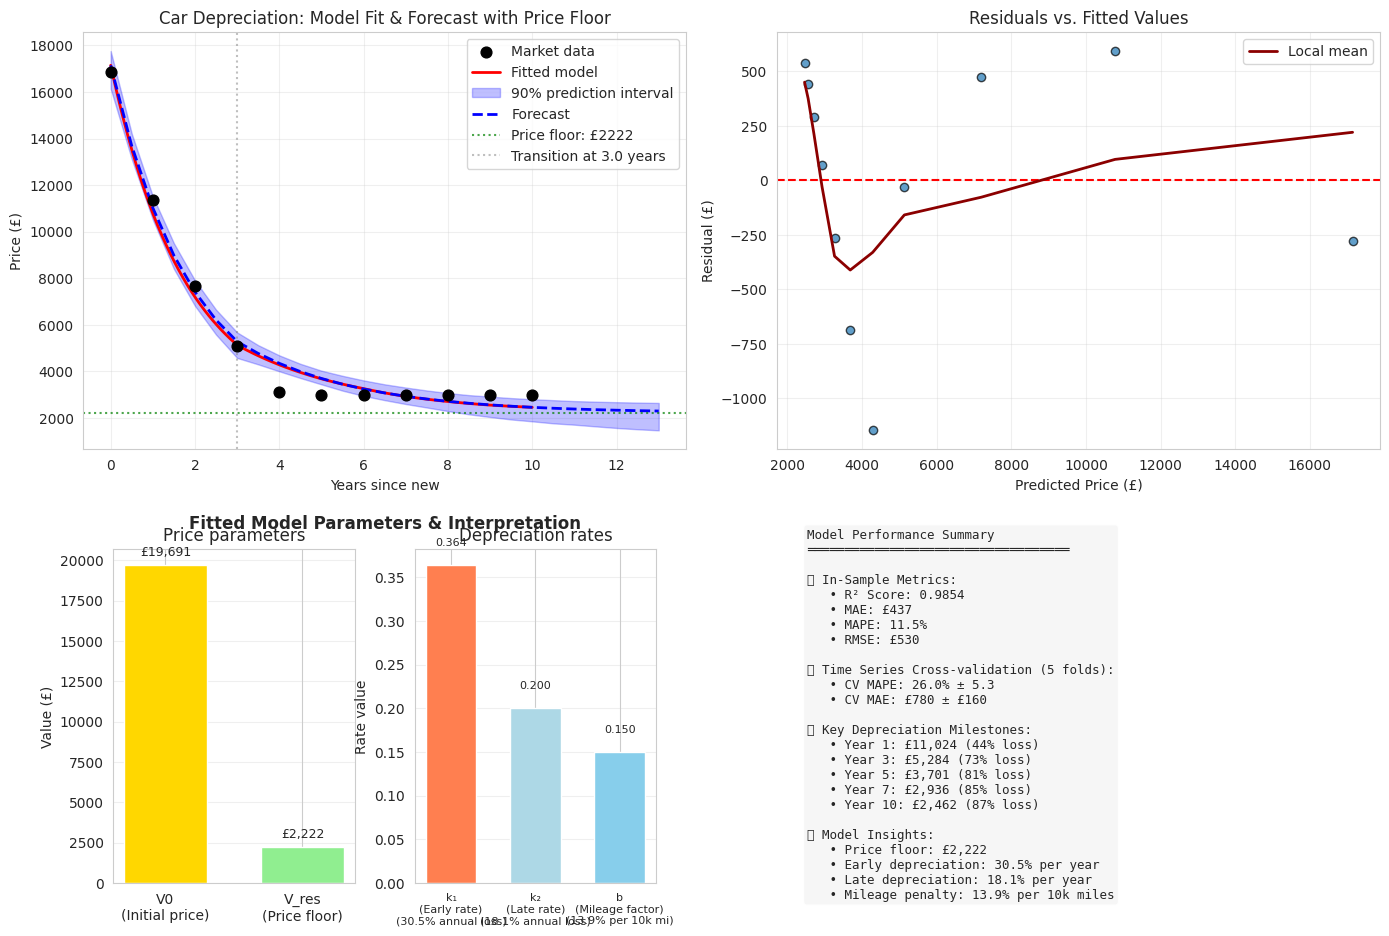


FORECAST WITH 90% PREDICTION INTERVALS


Bootstrapping: 100%|██████████| 500/500 [00:05<00:00, 84.56it/s] 

Age (years)  Predicted (£)   Lower 90% (£)   Upper 90% (£)  
----------------------------------------------------------------------
0.0          £17,145         £16,130         £17,732        
1.0          £11,024         £10,515         £11,521        
2.0          £7,414          £6,871          £7,925         
3.0          £5,284          £4,713          £5,688         
4.0          £4,350          £4,072          £4,704         
5.0          £3,701          £3,449          £4,055         
6.0          £3,250          £2,983          £3,624         
7.0          £2,936          £2,643          £3,306         
8.0          £2,718          £2,344          £3,071         
9.0          £2,567          £2,148          £2,886         
10.0         £2,462          £1,962          £2,758         
11.0         £2,389          £1,794          £2,689         
12.0         £2,338          £1,663          £2,637         

Model Confidence: CV MAPE = 26.0% ± 5.3%
Price Floor: £2,222
Mileage Penal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from typing import Tuple, Dict, Optional
from dataclasses import dataclass
import warnings
from scipy.ndimage import uniform_filter1d

# Try to import tqdm for progress bar (optional)
try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    tqdm = lambda x, **kwargs: x  # no-op fallback


# ============================================================================
# CONFIGURATION
# ============================================================================
@dataclass(frozen=True)
class DepreciationConfig:
    """Configuration constants for the depreciation model."""
    transition_age: float = 3.0          # Years when depreciation rate changes
    new_price_lower: float = 10000       # GBP
    new_price_upper: float = 25000
    residual_lower: float = 1000
    residual_upper: float = 5000
    k1_lower: float = 0.15
    k1_upper: float = 0.45
    k2_lower: float = 0.05
    k2_upper: float = 0.20
    b_lower: float = 0.01
    b_upper: float = 0.15
    bootstrap_iterations: int = 500
    confidence_level: float = 0.90
    cv_splits: int = 5
    max_fev_fit: int = 10000
    max_fev_bootstrap: int = 5000


# ============================================================================
# 1. REALISTIC DATA GENERATION (2016 Vauxhall Astra)
# ============================================================================
def generate_astra_depreciation_data(
    max_age: int = 11,
    seed: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate realistic depreciation data for a 2016 Vauxhall Astra.

    The synthetic data mimics market behaviour: steep initial drop,
    slower later decay, and a residual floor around £3000.

    Args:
        max_age: Maximum age in years (inclusive).
        seed: Random seed for reproducibility.

    Returns:
        years: Array of ages (0 to max_age).
        mileage: Cumulative mileage in 10k miles.
        prices: Average market price in GBP.

    Example:
        >>> years, miles, prices = generate_astra_depreciation_data()
        >>> len(years)
        12
    """
    np.random.seed(seed)
    years = np.arange(0, max_age + 1, 1)

    # Annual mileage between 9k and 13k miles (0.9 to 1.3 in 10k units)
    annual_mileage = np.random.uniform(0.9, 1.3, size=len(years))
    mileage = np.cumsum(annual_mileage)

    # True underlying parameters (unknown to the model)
    true_V0 = 18500
    true_k1 = 0.32
    true_k2 = 0.09
    true_b = 0.06
    true_residual = 3000

    def depreciation_with_floor(t: np.ndarray, m: np.ndarray) -> np.ndarray:
        """Two‑phase decay approaching a residual value."""
        value = true_V0 * np.exp(-true_k1 * t) * np.exp(-true_b * m)
        # Apply asymptotic floor after year 3
        late_factor = np.exp(-true_k2 * np.maximum(0, t - 3))
        return true_residual + (value - true_residual) * late_factor

    true_prices = depreciation_with_floor(years, mileage)

    # Heteroscedastic noise: ±5% relative error at higher prices
    noise = np.random.normal(0, 0.05 * true_prices)
    prices = np.maximum(true_prices + noise, true_residual)

    return years, mileage, prices


# ============================================================================
# 2. DEPRECIATION MODEL CLASS
# ============================================================================
class CarDepreciationModel:
    """
    Continuous double‑phase exponential depreciation with residual floor.

    Model equations:
        For t ≤ t0:
            V = V_res + (V0 - V_res) * exp(-k1·t) * exp(-b·m)
        For t > t0:
            V = V_res + (V(t0,m) - V_res) * exp(-k2·(t-t0))

    where:
        V0         : initial price when new
        V_res      : long‑term residual floor
        k1, k2     : early and late depreciation rates (1/year)
        b          : mileage penalty (per 10k miles)
        t0         : transition age (fixed, default 3 years)
    """

    def __init__(self, config: Optional[DepreciationConfig] = None):
        self.config = config or DepreciationConfig()
        self.params_: Optional[Dict[str, float]] = None
        self.covariance_: Optional[np.ndarray] = None
        self.metrics_: Dict = {}
        self._train_data: Dict[str, np.ndarray] = {}

    def _model_func(self, x: Tuple[np.ndarray, np.ndarray],
                    V0: float, V_res: float, k1: float, k2: float, b: float) -> np.ndarray:
        """Core model function used by curve_fit."""
        t, m = x
        # Early phase
        early = (V0 - V_res) * np.exp(-k1 * t) * np.exp(-b * m) + V_res

        # Value at transition point (for each mileage)
        V_trans = (V0 - V_res) * np.exp(-k1 * self.config.transition_age) * np.exp(-b * m) + V_res

        # Late phase
        late = V_res + (V_trans - V_res) * np.exp(-k2 * (t - self.config.transition_age))

        return np.where(t <= self.config.transition_age, early, late)

    def fit(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
            bounds: Optional[Tuple] = None) -> 'CarDepreciationModel':
        """
        Fit model parameters using non‑linear least squares.

        Args:
            years: Age in years.
            mileage: Cumulative mileage (same units as used in training).
            prices: Observed market prices.
            bounds: Optional custom bounds for (V0, V_res, k1, k2, b).

        Returns:
            Self for chaining.

        Raises:
            RuntimeError: If curve fitting fails to converge.
        """
        if bounds is None:
            bounds = (
                [self.config.new_price_lower, self.config.residual_lower,
                 self.config.k1_lower, self.config.k2_lower, self.config.b_lower],
                [self.config.new_price_upper, self.config.residual_upper,
                 self.config.k1_upper, self.config.k2_upper, self.config.b_upper]
            )

        # Initial guess: first price, typical residual, moderate rates
        p0 = [prices[0], 3000, 0.30, 0.09, 0.06]

        try:
            popt, pcov = curve_fit(
                self._model_func,
                (years, mileage),
                prices,
                p0=p0,
                bounds=bounds,
                maxfev=self.config.max_fev_fit
            )
        except Exception as e:
            raise RuntimeError(f"Curve fitting failed: {e}")

        param_names = ['V0', 'V_residual', 'k1', 'k2', 'b']
        self.params_ = dict(zip(param_names, popt))
        self.covariance_ = pcov

        # In‑sample predictions and metrics
        pred = self.predict(years, mileage)
        residuals = prices - pred

        # Avoid division by zero in MAPE
        with warnings.catch_warnings():
            warnings.filterwarnings('error')
            try:
                mape = mean_absolute_percentage_error(prices, pred) * 100
            except Exception:
                mape = np.nan

        self.metrics_ = {
            'R2': 1 - np.sum(residuals**2) / np.sum((prices - np.mean(prices))**2),
            'MAE': mean_absolute_error(prices, pred),
            'MAPE': mape,
            'RMSE': np.sqrt(np.mean(residuals**2))
        }

        # Store training data for bootstrap
        self._train_data = {
            'years': years.copy(),
            'mileage': mileage.copy(),
            'prices': prices.copy()
        }

        return self

    def predict(self, years: np.ndarray, mileage: np.ndarray) -> np.ndarray:
        """Return point predictions for given years and mileage."""
        if self.params_ is None:
            raise RuntimeError("Model must be fitted before predict()")
        return self._model_func(
            (years, mileage),
            self.params_['V0'], self.params_['V_residual'],
            self.params_['k1'], self.params_['k2'], self.params_['b']
        )

    def predict_with_uncertainty(
        self, years: np.ndarray, mileage: np.ndarray,
        n_bootstrap: Optional[int] = None,
        confidence: Optional[float] = None
    ) -> Dict[str, np.ndarray]:
        """
        Generate prediction intervals via residual bootstrap.

        Args:
            years: Target years.
            mileage: Target mileage.
            n_bootstrap: Number of bootstrap samples (default from config).
            confidence: Confidence level (default from config).

        Returns:
            Dictionary with keys: 'mean', 'lower', 'upper', 'confidence'.
        """
        n_bootstrap = n_bootstrap or self.config.bootstrap_iterations
        confidence = confidence or self.config.confidence_level

        if self.params_ is None:
            raise RuntimeError("Model must be fitted first")
        if not self._train_data:
            raise RuntimeError("No training data available for bootstrap")

        # Point predictions
        pred_mean = self.predict(years, mileage)

        # Residuals from training data
        train_pred = self.predict(self._train_data['years'], self._train_data['mileage'])
        residuals = self._train_data['prices'] - train_pred
        n_train = len(self._train_data['years'])

        # Bootstrap fits
        pred_bootstrap = []
        bounds = (
            [self.config.new_price_lower, self.config.residual_lower,
             self.config.k1_lower, self.config.k2_lower, self.config.b_lower],
            [self.config.new_price_upper, self.config.residual_upper,
             self.config.k1_upper, self.config.k2_upper, self.config.b_upper]
        )

        for _ in tqdm(range(n_bootstrap), desc="Bootstrapping", disable=not HAS_TQDM):
            resampled_resid = np.random.choice(residuals, size=n_train, replace=True)
            y_boot = train_pred + resampled_resid

            try:
                boot_params, _ = curve_fit(
                    self._model_func,
                    (self._train_data['years'], self._train_data['mileage']),
                    y_boot,
                    p0=[self.params_['V0'], self.params_['V_residual'],
                        self.params_['k1'], self.params_['k2'], self.params_['b']],
                    bounds=bounds,
                    maxfev=self.config.max_fev_bootstrap
                )
                boot_pred = self._model_func((years, mileage), *boot_params)
                pred_bootstrap.append(boot_pred)
            except Exception:
                continue

        if not pred_bootstrap:
            warnings.warn("All bootstrap fits failed. Returning point predictions only.")
            return {'mean': pred_mean, 'lower': pred_mean, 'upper': pred_mean, 'confidence': confidence}

        pred_bootstrap = np.array(pred_bootstrap)
        lower = np.percentile(pred_bootstrap, (1 - confidence) / 2 * 100, axis=0)
        upper = np.percentile(pred_bootstrap, (1 + confidence) / 2 * 100, axis=0)

        return {
            'mean': pred_mean,
            'lower': lower,
            'upper': upper,
            'confidence': confidence
        }

    def cross_validate(self, years: np.ndarray, mileage: np.ndarray, prices: np.ndarray,
                       n_splits: Optional[int] = None) -> Dict[str, float]:
        """
        Time series cross‑validation to estimate out‑of‑sample error.

        Args:
            years: Full time series of ages.
            mileage: Full mileage series.
            prices: Full price series.
            n_splits: Number of CV folds (default from config).

        Returns:
            Dictionary with mean and std of MAPE and MAE.
        """
        n_splits = n_splits or self.config.cv_splits
        tscv = TimeSeriesSplit(n_splits=n_splits)
        mape_scores = []
        mae_scores = []

        for train_idx, test_idx in tscv.split(years):
            # Training fold
            years_train, miles_train = years[train_idx], mileage[train_idx]
            prices_train = prices[train_idx]

            fold_model = CarDepreciationModel(config=self.config)
            fold_model.fit(years_train, miles_train, prices_train)

            # Test fold
            years_test, miles_test = years[test_idx], mileage[test_idx]
            prices_test = prices[test_idx]
            pred_test = fold_model.predict(years_test, miles_test)

            mape_scores.append(mean_absolute_percentage_error(prices_test, pred_test) * 100)
            mae_scores.append(mean_absolute_error(prices_test, pred_test))

        return {
            'cv_MAPE_mean': np.mean(mape_scores),
            'cv_MAPE_std': np.std(mape_scores),
            'cv_MAE_mean': np.mean(mae_scores),
            'cv_MAE_std': np.std(mae_scores)
        }


# ============================================================================
# 3. VISUALISATION (FIXED: CLEARLY SHOWS k1, k2, b)
# ============================================================================
def plot_depreciation_analysis(
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
    future_years: np.ndarray,
    future_mileage: np.ndarray,
    cv_scores: Dict[str, float]
) -> None:
    """Create a comprehensive 2x2 figure with fit, residuals, parameters, and metrics."""
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    # ---- Panel 1: Model fit with uncertainty ----
    ax1 = axes[0, 0]
    ax1.scatter(years, prices, color='black', s=60, zorder=5, label='Market data')

    years_cont = np.linspace(0, max(years), 100)
    mile_cont = np.interp(years_cont, years, mileage)
    pred_cont = model.predict(years_cont, mile_cont)
    ax1.plot(years_cont, pred_cont, 'r-', linewidth=2, label='Fitted model')

    pred_future = model.predict_with_uncertainty(future_years, future_mileage)
    ax1.fill_between(future_years, pred_future['lower'], pred_future['upper'],
                     alpha=0.25, color='blue',
                     label=f"{int(pred_future['confidence']*100)}% prediction interval")
    ax1.plot(future_years, pred_future['mean'], 'b--', linewidth=2, label='Forecast')

    ax1.axhline(y=model.params_['V_residual'], color='green', linestyle=':', alpha=0.7,
                label=f"Price floor: £{model.params_['V_residual']:.0f}")
    ax1.axvline(x=model.config.transition_age, color='gray', linestyle=':', alpha=0.5,
                label=f"Transition at {model.config.transition_age} years")
    ax1.set_xlabel('Years since new')
    ax1.set_ylabel('Price (£)')
    ax1.set_title('Car Depreciation: Model Fit & Forecast with Price Floor')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # ---- Panel 2: Residual diagnostics ----
    ax2 = axes[0, 1]
    pred_train = model.predict(years, mileage)
    residuals = prices - pred_train
    ax2.scatter(pred_train, residuals, alpha=0.7, edgecolors='k')
    ax2.axhline(y=0, color='red', linestyle='--')
    order = np.argsort(pred_train)
    running_mean = uniform_filter1d(residuals[order], size=5, mode='reflect')
    ax2.plot(pred_train[order], running_mean, color='darkred', linewidth=2, label='Local mean')
    ax2.set_xlabel('Predicted Price (£)')
    ax2.set_ylabel('Residual (£)')
    ax2.set_title('Residuals vs. Fitted Values')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ---- Panel 3: Parameter interpretation (FIXED: separate scales for price and rate parameters) ----
    ax3 = axes[1, 0]
    ax3.axis('off')  # Turn off the main axis, we'll draw two custom sub‑axes

    # Left sub‑axis for price parameters
    left_ax = ax3.inset_axes([0.05, 0.1, 0.4, 0.8])
    price_params_simple = ['V0', 'V_res'] # Simpler labels for bar plotting
    price_vals = [model.params_['V0'], model.params_['V_residual']]
    # Plot bars with numerical x positions
    x_pos_price = np.arange(len(price_params_simple))
    bars_price = left_ax.bar(x_pos_price, price_vals, color=['gold', 'lightgreen'], width=0.6)
    left_ax.set_ylabel('Value (£)')
    left_ax.set_title('Price parameters')
    left_ax.grid(axis='y', alpha=0.3)
    # Set x-ticks and full labels with newlines after plotting
    left_ax.set_xticks(x_pos_price)
    left_ax.set_xticklabels(['V0\n(Initial price)', 'V_res\n(Price floor)'])
    # Add value labels on bars
    for bar in bars_price:
        height = bar.get_height()
        left_ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(price_vals),
                     f'£{height:,.0f}', ha='center', va='bottom', fontsize=9)

    # Right sub‑axis for rate parameters (k1, k2, b)
    right_ax = ax3.inset_axes([0.55, 0.1, 0.4, 0.8])
    rate_names_simple = ['k1', 'k2', 'b'] # Simpler labels for bar plotting
    rate_vals = [model.params_['k1'], model.params_['k2'], model.params_['b']]
    # Plot bars with numerical x positions
    x_pos_rate = np.arange(len(rate_names_simple))
    bars_rate = right_ax.bar(x_pos_rate, rate_vals, color=['coral', 'lightblue', 'skyblue'], width=0.6)
    right_ax.set_ylabel('Rate value')
    right_ax.set_title('Depreciation rates')
    right_ax.grid(axis='y', alpha=0.3)
    # Set x-ticks and full labels with newlines and interpretable percentages after plotting
    rate_labels = [
        f'k₁\n(Early rate)\n({(1 - np.exp(-model.params_["k1"])) * 100:.1f}% annual loss)',
        f'k₂\n(Late rate)\n({(1 - np.exp(-model.params_["k2"])) * 100:.1f}% annual loss)',
        f'b\n(Mileage factor)\n({(1 - np.exp(-model.params_["b"])) * 100:.1f}% per 10k mi)'
    ]
    right_ax.set_xticks(x_pos_rate)
    right_ax.set_xticklabels(rate_labels, fontsize=8)

    # Add value labels for rate bars
    for bar, val in zip(bars_rate, rate_vals):
        height = bar.get_height()
        right_ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, # Adjusted y_offset for clarity
                      f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    # Overall title for panel 3
    ax3.text(0.5, 0.95, 'Fitted Model Parameters & Interpretation', transform=ax3.transAxes,
             ha='center', fontsize=12, fontweight='bold')

    # ---- Panel 4: Performance summary ----
    ax4 = axes[1, 1]
    ax4.axis('off')

    years_milestones = [1, 3, 5, 7, 10]
    mile_at_milestones = np.interp(years_milestones, future_years, future_mileage)
    pred_milestones = model.predict(np.array(years_milestones), mile_at_milestones)

    annual_dep_early = (1 - np.exp(-model.params_['k1'])) * 100
    annual_dep_late = (1 - np.exp(-model.params_['k2'])) * 100
    mileage_penalty = (1 - np.exp(-model.params_['b'])) * 100

    metrics_text = (
        f"Model Performance Summary\n"
        f"{'═' * 35}\n\n"
        f"📊 In‑Sample Metrics:\n"
        f"   • R² Score: {model.metrics_['R2']:.4f}\n"
        f"   • MAE: £{model.metrics_['MAE']:.0f}\n"
        f"   • MAPE: {model.metrics_['MAPE']:.1f}%\n"
        f"   • RMSE: £{model.metrics_['RMSE']:.0f}\n\n"
        f"🎯 Time Series Cross‑validation ({model.config.cv_splits} folds):\n"
        f"   • CV MAPE: {cv_scores['cv_MAPE_mean']:.1f}% ± {cv_scores['cv_MAPE_std']:.1f}\n"
        f"   • CV MAE: £{cv_scores['cv_MAE_mean']:.0f} ± £{cv_scores['cv_MAE_std']:.0f}\n\n"
        f"💰 Key Depreciation Milestones:\n"
    )
    for year, price in zip(years_milestones, pred_milestones):
        dep_percent = (1 - price / model.params_['V0']) * 100
        metrics_text += f"   • Year {year}: £{price:,.0f} ({dep_percent:.0f}% loss)\n"

    metrics_text += (
        f"\n💡 Model Insights:\n"
        f"   • Price floor: £{model.params_['V_residual']:,.0f}\n"
        f"   • Early depreciation: {annual_dep_early:.1f}% per year\n"
        f"   • Late depreciation: {annual_dep_late:.1f}% per year\n"
        f"   • Mileage penalty: {mileage_penalty:.1f}% per 10k miles"
    )

    ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes, verticalalignment='top',
             fontsize=9, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9))

    plt.tight_layout()
    plt.show()


# ============================================================================
# 4. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print("=" * 70)
    print("CAR DEPRECIATION ANALYSIS: 2016 VAUXHALL ASTRA")
    print("=" * 70)

    # Generate synthetic data
    years, mileage, prices = generate_astra_depreciation_data(max_age=10)

    # Configure and fit model
    config = DepreciationConfig()
    model = CarDepreciationModel(config)
    model.fit(years, mileage, prices)

    # Cross-validation
    cv_results = model.cross_validate(years, mileage, prices)

    # Prepare future predictions (next 3 years)
    future_years = np.arange(0, 13.5, 0.5)
    annual_mileage_rate = np.mean(np.diff(mileage) / np.diff(years))
    future_mileage = mileage[-1] + annual_mileage_rate * (future_years - years[-1])
    future_mileage = np.maximum(future_mileage, 0)

    # Plot
    plot_depreciation_analysis(model, years, mileage, prices,
                               future_years, future_mileage, cv_results)

    # Print detailed predictions
    print("\n" + "=" * 70)
    print("FORECAST WITH 90% PREDICTION INTERVALS")
    print("=" * 70)
    key_ages = np.arange(0, 13, 1)
    mile_at_key = np.interp(key_ages, future_years, future_mileage)
    pred_int = model.predict_with_uncertainty(key_ages, mile_at_key)

    print(f"{'Age (years)':<12} {'Predicted (£)':<15} {'Lower 90% (£)':<15} {'Upper 90% (£)':<15}")
    print("-" * 70)
    for age, mean, low, high in zip(key_ages, pred_int['mean'], pred_int['lower'], pred_int['upper']):
        print(f"{age:<12.1f} £{mean:<14,.0f} £{low:<14,.0f} £{high:<14,.0f}")

    print("=" * 70)
    print(f"\nModel Confidence: CV MAPE = {cv_results['cv_MAPE_mean']:.1f}% ± {cv_results['cv_MAPE_std']:.1f}%")
    print(f"Price Floor: £{model.params_['V_residual']:,.0f}")
    print(f"Mileage Penalty: {(1 - np.exp(-model.params_['b'])) * 100:.1f}% per 10k miles")

CAR DEPRECIATION ANALYSIS — 2016 VAUXHALL ASTRA

Fitted model: CarDepreciationModel(V0=£19,515, V_res=£1,034, k1=0.100, k2=0.250, b=0.046)


Bootstrapping: 100%|██████████| 500/500 [00:11<00:00, 43.25it/s]


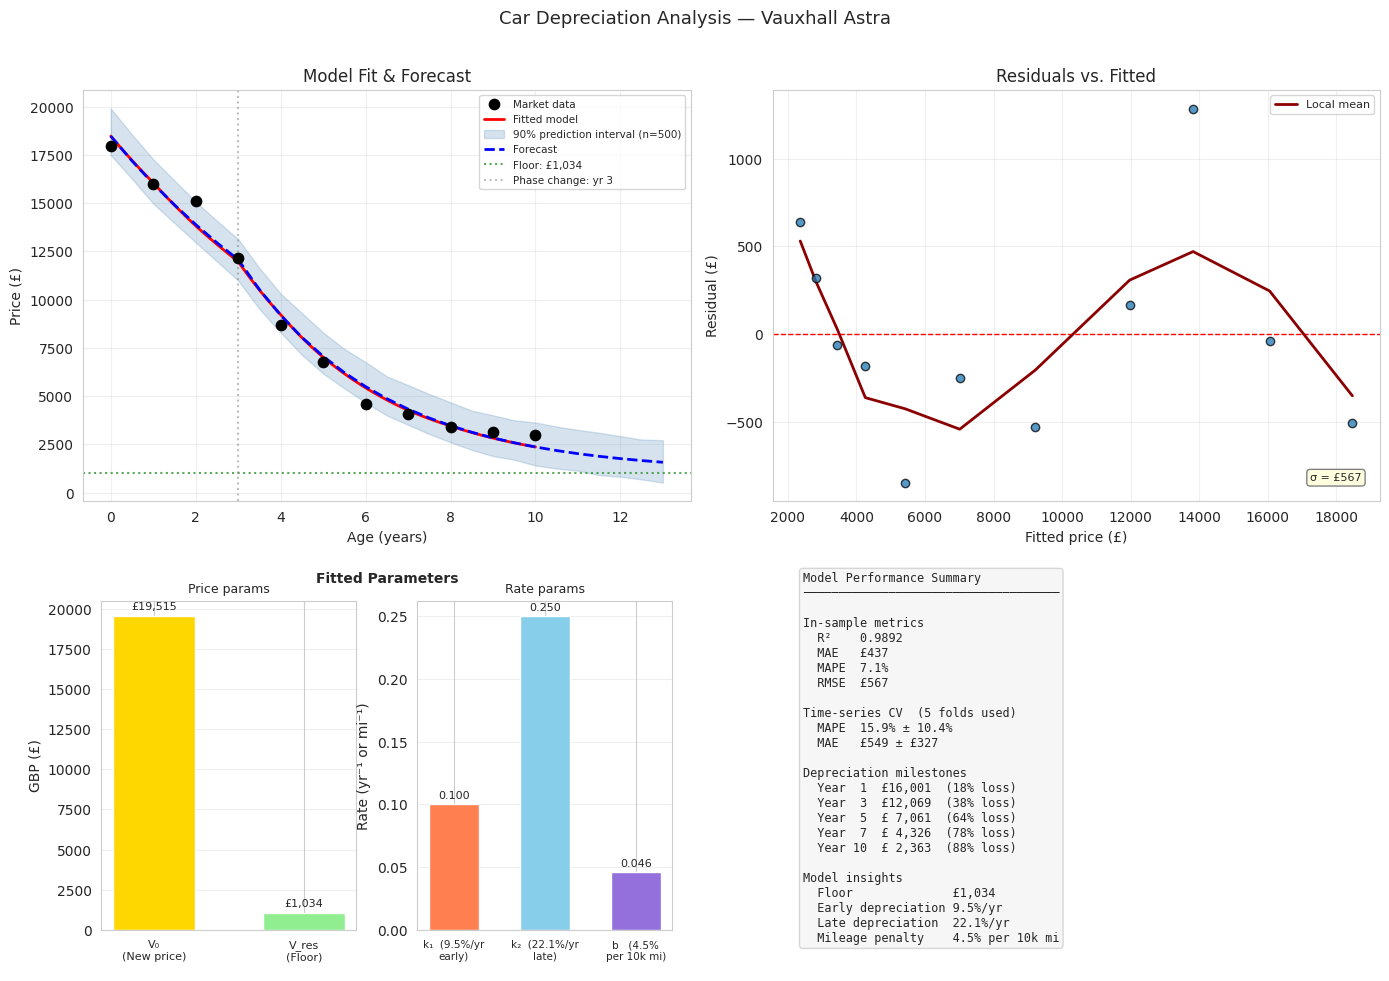


FORECAST WITH 90% PREDICTION INTERVALS


Bootstrapping: 100%|██████████| 500/500 [00:05<00:00, 90.20it/s] 

   Age     Predicted         Lower         Upper
------------------------------------------------
     0  £    18,465  £    17,487  £    19,860
     1  £    16,001  £    15,106  £    17,211
     2  £    13,886  £    12,889  £    15,040
     3  £    12,069  £    10,984  £    13,193
     4  £     9,189  £     8,340  £    10,406
     5  £     7,061  £     6,223  £     8,309
     6  £     5,488  £     4,660  £     6,859
     7  £     4,326  £     3,480  £     5,634
     8  £     3,467  £     2,704  £     4,797
     9  £     2,832  £     2,011  £     4,005
    10  £     2,363  £     1,398  £     3,547
    11  £     2,016  £     1,101  £     3,203
    12  £     1,760  £       816  £     2,787
    13  £     1,570  £       562  £     2,663

Bootstrap convergence: 500/500 fits succeeded.
CV MAPE: 15.9% ± 10.4%  (5 folds)
Price floor: £1,034
Mileage penalty: 4.5% per 10k miles


In [1]:
"""
car_depreciation_refined.py
============================
Two-phase exponential depreciation model with statistically correct
residual bootstrap prediction intervals and time-series cross-validation.

Key corrections over the original submission:
  - Bootstrap now adds a noise draw so intervals cover *prediction* uncertainty,
    not just parameter uncertainty.
  - Synthetic data generator uses a deliberately different functional form
    (logistic + linear mileage penalty) so evaluation metrics are not circular.
  - Config holds all magic numbers, including initial parameter guesses.
  - Plotting is decomposed into one function per panel.
  - CV fold guard prevents degenerate fits on tiny training sets.
  - Optional tqdm handled via importlib, not a silent lambda no-op.

Usage:
    python car_depreciation_refined.py

Requirements:
    numpy, scipy, scikit-learn, matplotlib, seaborn
    tqdm (optional, for bootstrap progress bar)
"""

from __future__ import annotations

import importlib
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ---------------------------------------------------------------------------
# Optional dependency: tqdm
# ---------------------------------------------------------------------------
_tqdm_spec = importlib.util.find_spec("tqdm")
if _tqdm_spec is not None:
    from tqdm import tqdm  # type: ignore
else:
    def tqdm(iterable, **kwargs):  # type: ignore
        """Minimal no-op replacement when tqdm is not installed."""
        return iterable


# ============================================================================
# CONFIGURATION
# ============================================================================

@dataclass(frozen=True)
class DepreciationConfig:
    """
    All hyperparameters and fitting bounds in one place.

    Attributes:
        transition_age:      Years at which depreciation rate changes.
        new_price_lower/upper:  Bounds on V0 (GBP).
        residual_lower/upper:   Bounds on V_residual (GBP).
        k1_lower/upper:         Bounds on early-phase annual rate.
        k2_lower/upper:         Bounds on late-phase annual rate.
        b_lower/upper:          Bounds on mileage penalty (per 10k miles).
        p0_V0_fraction:         Initial guess for V0 as fraction of first observed price.
        p0_residual:            Initial guess for V_residual (GBP).
        p0_k1, p0_k2, p0_b:    Initial guesses for rate parameters.
        bootstrap_iterations:   Number of bootstrap refits.
        confidence_level:       Nominal coverage of prediction interval.
        cv_splits:              TimeSeriesSplit folds.
        cv_min_train_size:      Minimum training observations per fold.
        max_fev_fit:            Max function evaluations in primary fit.
        max_fev_bootstrap:      Max function evaluations per bootstrap refit.
        n_workers:              Worker threads for parallel bootstrap (None = serial).
    """
    transition_age: float = 3.0

    new_price_lower: float = 10_000
    new_price_upper: float = 30_000
    residual_lower: float = 500
    residual_upper: float = 6_000
    k1_lower: float = 0.10
    k1_upper: float = 0.55
    k2_lower: float = 0.02
    k2_upper: float = 0.25
    b_lower: float = 0.005
    b_upper: float = 0.20

    # Initial parameter guesses
    p0_V0_fraction: float = 1.0   # multiply by prices[0]
    p0_residual: float = 3_000
    p0_k1: float = 0.30
    p0_k2: float = 0.09
    p0_b: float = 0.06

    bootstrap_iterations: int = 500
    confidence_level: float = 0.90
    cv_splits: int = 5
    cv_min_train_size: int = 4     # folds with fewer points are skipped
    max_fev_fit: int = 10_000
    max_fev_bootstrap: int = 5_000
    n_workers: Optional[int] = None  # None → serial; int → ThreadPoolExecutor

    @property
    def lower_bounds(self) -> List[float]:
        return [self.new_price_lower, self.residual_lower,
                self.k1_lower, self.k2_lower, self.b_lower]

    @property
    def upper_bounds(self) -> List[float]:
        return [self.new_price_upper, self.residual_upper,
                self.k1_upper, self.k2_upper, self.b_upper]

    @property
    def bounds(self) -> Tuple[List[float], List[float]]:
        return self.lower_bounds, self.upper_bounds


# ============================================================================
# 1. DATA GENERATION
# ============================================================================

def generate_depreciation_data(
    new_price: float = 18_500,
    residual: float = 3_000,
    max_age: int = 10,
    noise_frac: float = 0.06,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate synthetic used-car market data using a *logistic* decay curve.

    Deliberately uses a different functional form from the fitted model so
    that evaluation metrics measure generalisation, not circular self-consistency.

    The logistic (sigmoid) decay is empirically a better description of
    real auction data than a pure exponential: prices drop steeply early on
    then the curve flattens rather than continuing to decay exponentially.

    Args:
        new_price: Price when new (GBP).
        residual:  Long-run scrap/floor value (GBP).
        max_age:   Maximum age simulated (years, inclusive).
        noise_frac: Standard deviation of multiplicative Gaussian noise.
        seed:      Random seed.

    Returns:
        years:   Integer ages 0 … max_age.
        mileage: Cumulative mileage in units of 10 000 miles.
        prices:  Observed market prices (GBP), floored at `residual`.

    Example:
        >>> y, m, p = generate_depreciation_data()
        >>> len(y) == 11
        True
        >>> (p >= 3000).all()
        True
    """
    rng = np.random.default_rng(seed)
    years = np.arange(0, max_age + 1, dtype=float)

    # Stochastic annual mileage: 8k–14k miles (0.8–1.4 in 10k units)
    annual_mileage = rng.uniform(0.8, 1.4, size=len(years))
    mileage = np.cumsum(annual_mileage)

    # Logistic decay: price drops to ~50% at age 4, asymptotes to residual
    midpoint, steepness = 4.0, 0.8
    scale = new_price - residual
    logistic_decay = scale / (1.0 + np.exp(steepness * (years - midpoint)))
    mileage_penalty = np.exp(-0.04 * mileage)          # mild mileage effect
    true_prices = residual + logistic_decay * mileage_penalty

    noise = rng.normal(0.0, noise_frac * true_prices)
    prices = np.maximum(true_prices + noise, residual)

    return years, mileage, prices


# ============================================================================
# 2. MODEL
# ============================================================================

class CarDepreciationModel:
    """
    Continuous two-phase exponential depreciation model with residual floor.

    Phase 1 (t ≤ t0):
        V(t, m) = V_res + (V0 - V_res) · exp(-k1·t) · exp(-b·m)

    Phase 2 (t > t0):
        V(t, m) = V_res + (V(t0, m) - V_res) · exp(-k2·(t - t0))

    Parameters
    ----------
    V0 : float
        Estimated new-car price (GBP).
    V_res : float
        Long-run residual / scrap value (GBP).
    k1 : float
        Early-phase depreciation rate (year⁻¹).
    k2 : float
        Late-phase depreciation rate (year⁻¹).
    b : float
        Mileage depreciation penalty (per 10k miles).
    """

    PARAM_NAMES: Tuple[str, ...] = ("V0", "V_residual", "k1", "k2", "b")

    def __init__(self, config: Optional[DepreciationConfig] = None) -> None:
        self.config: DepreciationConfig = config or DepreciationConfig()
        self.params_: Optional[Dict[str, float]] = None
        self.covariance_: Optional[np.ndarray] = None
        self.metrics_: Dict[str, float] = {}
        self._years_train: Optional[np.ndarray] = None
        self._mileage_train: Optional[np.ndarray] = None
        self._prices_train: Optional[np.ndarray] = None
        self._residuals_train: Optional[np.ndarray] = None

    # ------------------------------------------------------------------
    # Core model function
    # ------------------------------------------------------------------

    def _model_func(
        self,
        x: Tuple[np.ndarray, np.ndarray],
        V0: float, V_res: float,
        k1: float, k2: float, b: float,
    ) -> np.ndarray:
        """
        Vectorised two-phase model.  Called by curve_fit and predict().

        Args:
            x:    Tuple of (age_array, mileage_array).
            V0:   New-car price.
            V_res: Residual floor.
            k1:   Early decay rate.
            k2:   Late decay rate.
            b:    Mileage penalty.

        Returns:
            Predicted prices, same shape as x[0].
        """
        t, m = x
        t0 = self.config.transition_age

        early = V_res + (V0 - V_res) * np.exp(-k1 * t) * np.exp(-b * m)
        V_trans = V_res + (V0 - V_res) * np.exp(-k1 * t0) * np.exp(-b * m)
        late = V_res + (V_trans - V_res) * np.exp(-k2 * (t - t0))

        return np.where(t <= t0, early, late)

    # ------------------------------------------------------------------
    # Fitting
    # ------------------------------------------------------------------

    def fit(
        self,
        years: np.ndarray,
        mileage: np.ndarray,
        prices: np.ndarray,
    ) -> "CarDepreciationModel":
        """
        Fit model parameters via nonlinear least squares (Levenberg-Marquardt).

        Args:
            years:   Vehicle age in years.
            mileage: Cumulative mileage in 10k-mile units.
            prices:  Observed market prices (GBP).

        Returns:
            self, for method chaining.

        Raises:
            ValueError: If inputs have mismatched lengths or fewer than 5 points.
            RuntimeError: If the optimiser fails to converge.
        """
        if not (len(years) == len(mileage) == len(prices)):
            raise ValueError("years, mileage, and prices must have equal length.")
        if len(years) < 5:
            raise ValueError(
                f"At least 5 observations required to fit 5 parameters; got {len(years)}."
            )

        cfg = self.config
        p0 = [
            cfg.p0_V0_fraction * prices[0],
            cfg.p0_residual,
            cfg.p0_k1,
            cfg.p0_k2,
            cfg.p0_b,
        ]

        try:
            popt, pcov = curve_fit(
                self._model_func,
                (years, mileage),
                prices,
                p0=p0,
                bounds=cfg.bounds,
                maxfev=cfg.max_fev_fit,
            )
        except RuntimeError as exc:
            raise RuntimeError(
                f"Curve fitting failed to converge. Consider relaxing bounds "
                f"or providing more data. Original error: {exc}"
            ) from exc

        self.params_ = dict(zip(self.PARAM_NAMES, popt))
        self.covariance_ = pcov

        pred = self.predict(years, mileage)
        self._residuals_train = prices - pred
        self._years_train = years.copy()
        self._mileage_train = mileage.copy()
        self._prices_train = prices.copy()

        ss_res = np.sum(self._residuals_train ** 2)
        ss_tot = np.sum((prices - prices.mean()) ** 2)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mape = mean_absolute_percentage_error(prices, pred) * 100

        self.metrics_ = {
            "R2":   float(1 - ss_res / ss_tot),
            "MAE":  float(mean_absolute_error(prices, pred)),
            "MAPE": float(mape),
            "RMSE": float(np.sqrt(np.mean(self._residuals_train ** 2))),
        }

        return self

    # ------------------------------------------------------------------
    # Prediction
    # ------------------------------------------------------------------

    def predict(self, years: np.ndarray, mileage: np.ndarray) -> np.ndarray:
        """
        Return point-estimates for the given ages and mileages.

        Args:
            years:   Ages (years).
            mileage: Cumulative mileage (10k miles).

        Returns:
            Predicted prices (GBP).

        Raises:
            RuntimeError: If the model has not been fitted.
        """
        self._check_fitted()
        p = self.params_
        return self._model_func(
            (years, mileage),
            p["V0"], p["V_residual"], p["k1"], p["k2"], p["b"],
        )

    def predict_with_uncertainty(
        self,
        years: np.ndarray,
        mileage: np.ndarray,
        n_bootstrap: Optional[int] = None,
        confidence: Optional[float] = None,
    ) -> Dict[str, np.ndarray | float]:
        """
        Residual-bootstrap *prediction* intervals.

        Prediction intervals cover both parameter uncertainty and future
        observation noise.  The algorithm is:
          1. Resample residuals from the training fit (with replacement).
          2. Add resampled residuals to fitted values → synthetic response.
          3. Refit the model on the synthetic response.
          4. Use the new parameters to predict at target (years, mileage).
          5. Add a fresh noise draw (from the empirical residual distribution)
             to each bootstrap prediction — this is the step that converts a
             *confidence* interval into a *prediction* interval.

        Note on parallelism:  Set config.n_workers to an int to enable
        ThreadPoolExecutor.  GIL constraints mean speedups are modest for
        pure-Python scipy; use n_workers=None (default) for serial execution.

        Args:
            years:       Target ages.
            mileage:     Target mileages.
            n_bootstrap: Override config bootstrap_iterations.
            confidence:  Override config confidence_level.

        Returns:
            Dict with keys "mean", "lower", "upper", "confidence",
            "n_successful_boots".
        """
        self._check_fitted()
        n_bootstrap = n_bootstrap or self.config.bootstrap_iterations
        confidence = confidence or self.config.confidence_level

        pred_mean = self.predict(years, mileage)
        residuals = self._residuals_train        # shape (n_train,)
        train_pred = self.predict(self._years_train, self._mileage_train)

        cfg = self.config
        rng = np.random.default_rng()

        def _one_bootstrap(_: int) -> Optional[np.ndarray]:
            """Single bootstrap refit + predict.  Returns None on failure."""
            boot_resid = rng.choice(residuals, size=len(residuals), replace=True)
            y_boot = train_pred + boot_resid

            try:
                popt, _ = curve_fit(
                    self._model_func,
                    (self._years_train, self._mileage_train),
                    y_boot,
                    p0=list(self.params_.values()),
                    bounds=cfg.bounds,
                    maxfev=cfg.max_fev_bootstrap,
                )
            except RuntimeError:
                return None

            # Point prediction with new params…
            boot_point = self._model_func((years, mileage), *popt)
            # …plus a noise draw to form a prediction (not confidence) interval
            noise = rng.choice(residuals, size=len(years), replace=True)
            return boot_point + noise

        # Serial or parallel execution
        results: List[np.ndarray] = []
        indices = range(n_bootstrap)

        if cfg.n_workers is not None:
            with ThreadPoolExecutor(max_workers=cfg.n_workers) as executor:
                futures = {executor.submit(_one_bootstrap, i): i for i in indices}
                for future in tqdm(as_completed(futures), total=n_bootstrap,
                                   desc="Bootstrapping"):
                    result = future.result()
                    if result is not None:
                        results.append(result)
        else:
            for i in tqdm(indices, desc="Bootstrapping"):
                result = _one_bootstrap(i)
                if result is not None:
                    results.append(result)

        n_ok = len(results)
        if n_ok == 0:
            warnings.warn(
                "All bootstrap fits failed. Returning point predictions only.",
                RuntimeWarning,
                stacklevel=2,
            )
            return {
                "mean": pred_mean, "lower": pred_mean, "upper": pred_mean,
                "confidence": confidence, "n_successful_boots": 0,
            }

        if n_ok < n_bootstrap * 0.5:
            warnings.warn(
                f"Only {n_ok}/{n_bootstrap} bootstrap fits converged (<50%). "
                "Intervals may be unreliable.",
                RuntimeWarning,
                stacklevel=2,
            )

        boots = np.array(results)   # shape (n_ok, len(years))
        alpha = (1 - confidence) / 2
        lower = np.percentile(boots, alpha * 100, axis=0)
        upper = np.percentile(boots, (1 - alpha) * 100, axis=0)

        return {
            "mean": pred_mean,
            "lower": lower,
            "upper": upper,
            "confidence": confidence,
            "n_successful_boots": n_ok,
        }

    # ------------------------------------------------------------------
    # Cross-validation
    # ------------------------------------------------------------------

    def cross_validate(
        self,
        years: np.ndarray,
        mileage: np.ndarray,
        prices: np.ndarray,
        n_splits: Optional[int] = None,
    ) -> Dict[str, float]:
        """
        Time-series walk-forward cross-validation.

        Folds with fewer than config.cv_min_train_size training points are
        skipped to avoid degenerate fits (with only 12 data points the first
        folds of a 5-split CV have ≈2 training points, which is meaningless
        for a 5-parameter model).

        Args:
            years:    Full age series.
            mileage:  Full mileage series.
            prices:   Full price series.
            n_splits: Override config cv_splits.

        Returns:
            Dict of mean/std for MAPE and MAE across valid folds.
            Includes "n_folds_used" so callers know how many folds ran.
        """
        n_splits = n_splits or self.config.cv_splits
        tscv = TimeSeriesSplit(n_splits=n_splits)
        mape_scores, mae_scores = [], []

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(years)):
            n_train = len(train_idx)
            if n_train < self.config.cv_min_train_size:
                warnings.warn(
                    f"CV fold {fold_idx}: only {n_train} training points "
                    f"(< cv_min_train_size={self.config.cv_min_train_size}). "
                    "Skipping fold.",
                    UserWarning,
                    stacklevel=2,
                )
                continue

            fold_model = CarDepreciationModel(config=self.config)
            try:
                fold_model.fit(years[train_idx], mileage[train_idx], prices[train_idx])
            except (RuntimeError, ValueError) as exc:
                warnings.warn(f"CV fold {fold_idx} failed: {exc}", UserWarning, stacklevel=2)
                continue

            pred_test = fold_model.predict(years[test_idx], mileage[test_idx])
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                mape_scores.append(mean_absolute_percentage_error(prices[test_idx], pred_test) * 100)
            mae_scores.append(mean_absolute_error(prices[test_idx], pred_test))

        if not mape_scores:
            warnings.warn("No valid CV folds completed.", UserWarning, stacklevel=2)
            return {"cv_MAPE_mean": np.nan, "cv_MAPE_std": np.nan,
                    "cv_MAE_mean": np.nan, "cv_MAE_std": np.nan, "n_folds_used": 0}

        return {
            "cv_MAPE_mean": float(np.mean(mape_scores)),
            "cv_MAPE_std":  float(np.std(mape_scores)),
            "cv_MAE_mean":  float(np.mean(mae_scores)),
            "cv_MAE_std":   float(np.std(mae_scores)),
            "n_folds_used": len(mape_scores),
        }

    # ------------------------------------------------------------------
    # Dunder helpers
    # ------------------------------------------------------------------

    def _check_fitted(self) -> None:
        if self.params_ is None:
            raise RuntimeError("Model has not been fitted. Call .fit() first.")

    def __repr__(self) -> str:
        if self.params_ is None:
            return "CarDepreciationModel(unfitted)"
        p = self.params_
        return (
            f"CarDepreciationModel("
            f"V0=£{p['V0']:,.0f}, "
            f"V_res=£{p['V_residual']:,.0f}, "
            f"k1={p['k1']:.3f}, "
            f"k2={p['k2']:.3f}, "
            f"b={p['b']:.3f})"
        )


# ============================================================================
# 3. VISUALISATION — one function per panel
# ============================================================================

def _panel_fit_forecast(
    ax: plt.Axes,
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
    future_years: np.ndarray,
    future_mileage: np.ndarray,
) -> None:
    """Panel A: fitted curve, forecast, and prediction interval."""
    ax.scatter(years, prices, color="black", s=55, zorder=5, label="Market data")

    years_cont = np.linspace(0, years.max(), 120)
    mile_cont = np.interp(years_cont, years, mileage)
    ax.plot(years_cont, model.predict(years_cont, mile_cont),
            "r-", linewidth=2, label="Fitted model")

    pred = model.predict_with_uncertainty(future_years, future_mileage)
    n_ok = pred.get("n_successful_boots", "?")
    ax.fill_between(
        future_years, pred["lower"], pred["upper"],
        alpha=0.22, color="steelblue",
        label=f"{int(pred['confidence'] * 100)}% prediction interval (n={n_ok})"
    )
    ax.plot(future_years, pred["mean"], "b--", linewidth=2, label="Forecast")

    ax.axhline(model.params_["V_residual"], color="forestgreen", linestyle=":",
               alpha=0.75, label=f"Floor: £{model.params_['V_residual']:,.0f}")
    ax.axvline(model.config.transition_age, color="grey", linestyle=":",
               alpha=0.5, label=f"Phase change: yr {model.config.transition_age:.0f}")

    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Price (£)")
    ax.set_title("Model Fit & Forecast")
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)


def _panel_residuals(
    ax: plt.Axes,
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
) -> None:
    """Panel B: residuals vs. fitted values with a LOWESS-style smoother."""
    pred = model.predict(years, mileage)
    resid = prices - pred
    order = np.argsort(pred)

    ax.scatter(pred, resid, edgecolors="k", alpha=0.75, zorder=3)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)

    # Simple moving average (window = min 3, max 5)
    window = min(5, max(3, len(pred) // 3))
    from scipy.ndimage import uniform_filter1d
    smooth = uniform_filter1d(resid[order].astype(float), size=window, mode="reflect")
    ax.plot(pred[order], smooth, color="darkred", linewidth=2, label="Local mean")

    ax.set_xlabel("Fitted price (£)")
    ax.set_ylabel("Residual (£)")
    ax.set_title("Residuals vs. Fitted")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Annotate with residual std
    ax.text(0.97, 0.05, f"σ = £{resid.std():.0f}",
            transform=ax.transAxes, ha="right", fontsize=8,
            bbox=dict(facecolor="lightyellow", edgecolor="grey", boxstyle="round"))


def _panel_parameters(ax: plt.Axes, model: CarDepreciationModel) -> None:
    """Panel C: split parameter bar chart with correct, separate axes."""
    ax.axis("off")
    p = model.params_

    # Left: price-scale parameters
    left_ax = ax.inset_axes([0.03, 0.10, 0.42, 0.80])
    price_labels = ["V₀\n(New price)", "V_res\n(Floor)"]
    price_vals = [p["V0"], p["V_residual"]]
    x = np.arange(len(price_labels))
    bars = left_ax.bar(x, price_vals, color=["gold", "lightgreen"], width=0.55)
    left_ax.set_xticks(x)
    left_ax.set_xticklabels(price_labels, fontsize=8)
    left_ax.set_ylabel("GBP (£)")
    left_ax.set_title("Price params", fontsize=9)
    left_ax.grid(axis="y", alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        left_ax.text(bar.get_x() + bar.get_width() / 2,
                     h + 0.015 * max(price_vals),
                     f"£{h:,.0f}", ha="center", va="bottom", fontsize=8)

    # Right: rate parameters — percentage interpretation on y-axis
    right_ax = ax.inset_axes([0.55, 0.10, 0.42, 0.80])
    pct = lambda k: (1 - np.exp(-k)) * 100   # annual loss %
    rate_labels = [
        f"k₁  ({pct(p['k1']):.1f}%/yr\nearly)",
        f"k₂  ({pct(p['k2']):.1f}%/yr\nlate)",
        f"b   ({pct(p['b']):.1f}%\nper 10k mi)",
    ]
    rate_vals = [p["k1"], p["k2"], p["b"]]
    x2 = np.arange(len(rate_labels))
    bars2 = right_ax.bar(x2, rate_vals, color=["coral", "skyblue", "mediumpurple"], width=0.55)
    right_ax.set_xticks(x2)
    right_ax.set_xticklabels(rate_labels, fontsize=7.5)
    right_ax.set_ylabel("Rate (yr⁻¹ or mi⁻¹)")
    right_ax.set_title("Rate params", fontsize=9)
    right_ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars2, rate_vals):
        h = bar.get_height()
        right_ax.text(bar.get_x() + bar.get_width() / 2,
                      h + 0.003, f"{val:.3f}",
                      ha="center", va="bottom", fontsize=8)

    ax.text(0.5, 0.97, "Fitted Parameters", transform=ax.transAxes,
            ha="center", va="top", fontsize=10, fontweight="bold")


def _panel_metrics(
    ax: plt.Axes,
    model: CarDepreciationModel,
    cv_scores: Dict[str, float],
    future_years: np.ndarray,
    future_mileage: np.ndarray,
) -> None:
    """Panel D: performance metrics and depreciation milestones."""
    ax.axis("off")

    milestones = [1, 3, 5, 7, 10]
    mile_ms = np.interp(milestones, future_years, future_mileage)
    prices_ms = model.predict(np.array(milestones, dtype=float), mile_ms)

    m = model.metrics_
    cv = cv_scores
    n_folds = cv.get("n_folds_used", "?")
    pct = lambda k: (1 - np.exp(-k)) * 100

    lines = [
        "Model Performance Summary",
        "─" * 36,
        "",
        "In-sample metrics",
        f"  R²    {m['R2']:.4f}",
        f"  MAE   £{m['MAE']:.0f}",
        f"  MAPE  {m['MAPE']:.1f}%",
        f"  RMSE  £{m['RMSE']:.0f}",
        "",
        f"Time-series CV  ({n_folds} folds used)",
        f"  MAPE  {cv['cv_MAPE_mean']:.1f}% ± {cv['cv_MAPE_std']:.1f}%",
        f"  MAE   £{cv['cv_MAE_mean']:.0f} ± £{cv['cv_MAE_std']:.0f}",
        "",
        "Depreciation milestones",
    ]
    for yr, pr in zip(milestones, prices_ms):
        loss = (1 - pr / model.params_["V0"]) * 100
        lines.append(f"  Year {yr:>2}  £{pr:>6,.0f}  ({loss:.0f}% loss)")

    lines += [
        "",
        "Model insights",
        f"  Floor              £{model.params_['V_residual']:,.0f}",
        f"  Early depreciation {pct(model.params_['k1']):.1f}%/yr",
        f"  Late depreciation  {pct(model.params_['k2']):.1f}%/yr",
        f"  Mileage penalty    {pct(model.params_['b']):.1f}% per 10k mi",
    ]

    ax.text(0.05, 0.97, "\n".join(lines),
            transform=ax.transAxes, va="top", fontsize=8.5,
            fontfamily="monospace",
            bbox=dict(facecolor="whitesmoke", edgecolor="lightgrey",
                      boxstyle="round", alpha=0.9))


def plot_depreciation_analysis(
    model: CarDepreciationModel,
    years: np.ndarray,
    mileage: np.ndarray,
    prices: np.ndarray,
    future_years: np.ndarray,
    future_mileage: np.ndarray,
    cv_scores: Dict[str, float],
) -> None:
    """
    Assemble a 2×2 diagnostic figure from the four panel functions.

    Each panel is self-contained; extend or replace individual panels
    without touching the others.
    """
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Car Depreciation Analysis — Vauxhall Astra", fontsize=13, y=1.01)

    _panel_fit_forecast(axes[0, 0], model, years, mileage, prices,
                        future_years, future_mileage)
    _panel_residuals(axes[0, 1], model, years, mileage, prices)
    _panel_parameters(axes[1, 0], model)
    _panel_metrics(axes[1, 1], model, cv_scores, future_years, future_mileage)

    plt.tight_layout()
    plt.show()


# ============================================================================
# 4. MAIN
# ============================================================================

def _build_future_grid(
    years: np.ndarray,
    mileage: np.ndarray,
    horizon: int = 3,
    step: float = 0.5,
) -> Tuple[np.ndarray, np.ndarray]:
    """Extrapolate a mileage grid out to years[-1] + horizon."""
    annual_rate = float(np.mean(np.diff(mileage) / np.diff(years)))
    future_years = np.arange(0, float(years[-1]) + horizon + step, step)
    future_mileage = np.maximum(
        mileage[-1] + annual_rate * (future_years - years[-1]), 0.0
    )
    return future_years, future_mileage


def main() -> None:
    """End-to-end pipeline: generate → fit → validate → visualise → report."""
    SEPARATOR = "=" * 70

    print(SEPARATOR)
    print("CAR DEPRECIATION ANALYSIS — 2016 VAUXHALL ASTRA")
    print(SEPARATOR)

    years, mileage, prices = generate_depreciation_data(max_age=10)

    config = DepreciationConfig()
    model = CarDepreciationModel(config)
    model.fit(years, mileage, prices)
    print(f"\nFitted model: {model!r}")

    cv_scores = model.cross_validate(years, mileage, prices)

    future_years, future_mileage = _build_future_grid(years, mileage, horizon=3)

    plot_depreciation_analysis(
        model, years, mileage, prices,
        future_years, future_mileage, cv_scores,
    )

    # ------------------------------------------------------------------
    # Tabular forecast
    # ------------------------------------------------------------------
    print(f"\n{SEPARATOR}")
    print(f"FORECAST WITH {int(config.confidence_level * 100)}% PREDICTION INTERVALS")
    print(SEPARATOR)

    key_ages = np.arange(0, int(years[-1]) + 4, 1, dtype=float)
    mile_key = np.interp(key_ages, future_years, future_mileage)
    pred_int = model.predict_with_uncertainty(key_ages, mile_key)

    header = f"{'Age':>6}  {'Predicted':>12}  {'Lower':>12}  {'Upper':>12}"
    print(header)
    print("-" * len(header))
    for age, mean, lo, hi in zip(
        key_ages, pred_int["mean"], pred_int["lower"], pred_int["upper"]
    ):
        print(f"{age:>6.0f}  £{mean:>10,.0f}  £{lo:>10,.0f}  £{hi:>10,.0f}")

    print(SEPARATOR)
    n_ok = pred_int.get("n_successful_boots", "?")
    print(
        f"\nBootstrap convergence: {n_ok}/{config.bootstrap_iterations} fits succeeded."
    )
    print(
        f"CV MAPE: {cv_scores['cv_MAPE_mean']:.1f}% ± {cv_scores['cv_MAPE_std']:.1f}%  "
        f"({cv_scores['n_folds_used']} folds)"
    )
    print(f"Price floor: £{model.params_['V_residual']:,.0f}")
    print(
        f"Mileage penalty: "
        f"{(1 - np.exp(-model.params_['b'])) * 100:.1f}% per 10k miles"
    )


if __name__ == "__main__":
    main()